# 2. Análisis Exploratorio de Datos (EDA)

Este capítulo reproduce las celdas 1–14 del notebook maestro `model_evaluation.ipynb`, con sus tablas y figuras guardadas. Incluye adquisición, preparación, período común, continuidad temporal, retornos, volatilidad de 30 horas y EDA. Las celdas de código conservan la etiqueta `skip-execution` para publicar las salidas existentes.

## 2.1 Configuración y adquisición de datos

El proyecto utiliza datos horarios de Binance Spot para cinco criptomonedas:

- BTCUSDT
- ETHUSDT
- BNBUSDT
- XRPUSDT
- SOLUSDT

La frecuencia utilizada es de una hora (`1h`).

Los datos serán descargados directamente desde la API pública de Binance para garantizar la reproducibilidad del proyecto.

La variable de interés será la volatilidad de los retornos logarítmicos.

El objetivo final será pronosticar simultáneamente los siguientes siete valores futuros de volatilidad mediante una red neuronal MLP multisalida.

In [2]:

import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# =========================================================
# CONFIGURACI?N GENERAL DEL PROYECTO
# =========================================================

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "XRPUSDT",
    "SOLUSDT",
]

INTERVAL = "1h"

START_DATE = "2020-01-01"
END_DATE = "2026-09-20"

BASE_URL = "https://data-api.binance.vision/api/v3/klines"

DATA_DIR = Path("data/processed")
DATA_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = DATA_DIR / "crypto_binance_master_1h.csv"

RANDOM_STATE = 42

INPUT_WINDOWS = [7, 14, 21, 28]
N_STEPS_FORECAST = 7
N_STEPS_JUMP = 1

print("Configuraci?n cargada correctamente.")
print("Criptomonedas:", SYMBOLS)
print("Frecuencia:", INTERVAL)
print("Periodo:", START_DATE, "a", END_DATE)
print("Ventanas de entrada:", INPUT_WINDOWS)
print("Horizonte de pron?stico:", N_STEPS_FORECAST)


Configuraci?n cargada correctamente.
Criptomonedas: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'SOLUSDT']
Frecuencia: 1h
Periodo: 2020-01-01 a 2026-09-20
Ventanas de entrada: [7, 14, 21, 28]
Horizonte de pron?stico: 7



### 2.1.1 Descarga de datos desde Binance Spot

Los datos OHLCV se obtienen directamente desde el endpoint público de Binance:

`https://data-api.binance.vision/api/v3/klines`

Para cada activo se descargan velas de una hora (`1h`) dentro del período de estudio.

Cada observación contiene las variables originales suministradas por Binance:

- Open time
- Open
- High
- Low
- Close
- Volume
- Close time
- Quote asset volume
- Number of trades
- Taker buy base asset volume
- Taker buy quote asset volume

Se conserva además el símbolo correspondiente a cada activo.

In [3]:

# =========================================================
# DESCARGA PAGINADA DE DATOS DESDE BINANCE SPOT
# =========================================================

KLINE_COLUMNS = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_asset_volume",
    "taker_buy_quote_asset_volume",
    "ignore",
]

NUMERIC_COLUMNS = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_asset_volume",
    "taker_buy_quote_asset_volume",
]

def download_binance_klines(
    symbol,
    interval,
    start_date,
    end_date,
    limit=1000,
    max_retries=5,
):
    """
    Descarga velas hist?ricas de Binance Spot utilizando paginaci?n.
    """

    start_timestamp = pd.Timestamp(start_date, tz="UTC")

    # END_DATE se interpreta como d?a completo.
    end_timestamp = (
        pd.Timestamp(end_date, tz="UTC")
        + pd.Timedelta(days=1)
        - pd.Timedelta(milliseconds=1)
    )

    start_ms = int(start_timestamp.timestamp() * 1000)
    end_ms = int(end_timestamp.timestamp() * 1000)

    all_rows = []
    current_start = start_ms

    session = requests.Session()

    print(f"\nDescargando {symbol}...")

    while current_start <= end_ms:

        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ms,
            "limit": limit,
        }

        data = None

        for attempt in range(1, max_retries + 1):
            try:
                response = session.get(
                    BASE_URL,
                    params=params,
                    timeout=30,
                )

                response.raise_for_status()
                data = response.json()
                break

            except requests.RequestException as error:
                print(
                    f"Intento {attempt}/{max_retries} "
                    f"fallido para {symbol}: {error}"
                )

                if attempt == max_retries:
                    raise

                time.sleep(2 * attempt)

        if not data:
            break

        all_rows.extend(data)

        last_open_time = int(data[-1][0])

        # Evita repetir la ?ltima observaci?n.
        next_start = last_open_time + 1

        if next_start <= current_start:
            break

        current_start = next_start

        if len(data) < limit:
            break

        # Peque?a pausa para evitar sobrecargar la API.
        time.sleep(0.05)

    if not all_rows:
        print(f"No se encontraron datos para {symbol}.")
        return pd.DataFrame(columns=KLINE_COLUMNS + ["symbol"])

    df_symbol = pd.DataFrame(
        all_rows,
        columns=KLINE_COLUMNS,
    )

    df_symbol["symbol"] = symbol

    df_symbol["open_time"] = pd.to_datetime(
        df_symbol["open_time"],
        unit="ms",
        utc=True,
    )

    df_symbol["close_time"] = pd.to_datetime(
        df_symbol["close_time"],
        unit="ms",
        utc=True,
    )

    for column in NUMERIC_COLUMNS:
        df_symbol[column] = pd.to_numeric(
            df_symbol[column],
            errors="coerce",
        )

    df_symbol["number_of_trades"] = (
        df_symbol["number_of_trades"]
        .fillna(0)
        .astype("int64")
    )

    df_symbol = (
        df_symbol
        .drop(columns=["ignore"])
        .drop_duplicates(
            subset=["symbol", "open_time"]
        )
        .sort_values("open_time")
        .reset_index(drop=True)
    )

    print(
        f"{symbol}: {len(df_symbol):,} observaciones | "
        f"{df_symbol['open_time'].min()} -> "
        f"{df_symbol['open_time'].max()}"
    )

    return df_symbol


# ---------------------------------------------------------
# DESCARGA O CARGA DESDE CACH? LOCAL
# ---------------------------------------------------------

FORCE_DOWNLOAD = False

if OUTPUT_FILE.exists() and not FORCE_DOWNLOAD:

    print("Archivo local encontrado.")
    print("Cargando:", OUTPUT_FILE)

    df = pd.read_csv(
        OUTPUT_FILE
    )

    df["open_time"] = pd.to_datetime(
        df["open_time"],
        format="mixed",
        utc=True,
    )

    df["close_time"] = pd.to_datetime(
        df["close_time"],
        format="mixed",
        utc=True,
    )

else:

    datasets = []

    for symbol in SYMBOLS:

        temp = download_binance_klines(
            symbol=symbol,
            interval=INTERVAL,
            start_date=START_DATE,
            end_date=END_DATE,
        )

        datasets.append(temp)

    df = pd.concat(
        datasets,
        ignore_index=True,
    )

    df = (
        df
        .sort_values(["symbol", "open_time"])
        .reset_index(drop=True)
    )

    df.to_csv(
        OUTPUT_FILE,
        index=False,
    )

    print("\nArchivo guardado correctamente:")
    print(OUTPUT_FILE)


# ---------------------------------------------------------
# VALIDACI?N INICIAL
# ---------------------------------------------------------

print("\nDimensiones del dataset:")
print(df.shape)

print("\nN?mero de observaciones por activo:")
print(
    df.groupby("symbol")
      .size()
      .sort_index()
)

print("\nPeriodo disponible por activo:")

period_summary = (
    df.groupby("symbol")
      .agg(
          fecha_inicial=("open_time", "min"),
          fecha_final=("open_time", "max"),
          observaciones=("open_time", "size"),
      )
)

display(period_summary)

print("\nPrimeras observaciones:")
display(df.head())


Archivo local encontrado.
Cargando: data\processed\crypto_binance_master_1h.csv



Dimensiones del dataset:
(289094, 12)

N?mero de observaciones por activo:
symbol
BNBUSDT    58888
BTCUSDT    58888
ETHUSDT    58888
SOLUSDT    53542
XRPUSDT    58888
dtype: int64

Periodo disponible por activo:


,fecha_inicial,fecha_final,observaciones
symbol,,,
BNBUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
BTCUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
ETHUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
SOLUSDT,2020-08-11 06:00:00+00:00,2026-09-20 23:00:00+00:00,53542
XRPUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888



Primeras observaciones:


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,symbol
0,2020-01-01 00:00:00+00:00,13.7159,13.7211,13.6903,13.6981,62016.69,2020-01-01 00:59:59.999000+00:00,8.498617e+05,974,40644.00,556987.169809,BNBUSDT
1,2020-01-01 01:00:00+00:00,13.6981,13.8000,13.6953,13.7995,53791.25,2020-01-01 01:59:59.999000+00:00,7.405759e+05,1613,31233.62,429983.786527,BNBUSDT
2,2020-01-01 02:00:00+00:00,13.7984,13.8488,13.7906,13.8478,75200.49,2020-01-01 02:59:59.999000+00:00,1.039091e+06,1738,50428.79,696827.231512,BNBUSDT
3,2020-01-01 03:00:00+00:00,13.8461,13.8500,13.7855,13.8170,35995.97,2020-01-01 03:59:59.999000+00:00,4.975018e+05,784,26728.89,369440.277768,BNBUSDT
4,2020-01-01 04:00:00+00:00,13.8157,13.8262,13.7801,13.7922,34409.55,2020-01-01 04:59:59.999000+00:00,4.751285e+05,784,21646.90,298923.160759,BNBUSDT



## 2.2 Preparación temporal de los datos

### 2.2.1 Período común entre los activos

Debido a que las criptomonedas no necesariamente poseen la misma fecha inicial de negociación, se determina un período temporal común para los cinco activos.

La fecha inicial común corresponde a la mayor de las fechas iniciales y la fecha final común corresponde a la menor de las fechas finales.

### 2.2.2 Verificación de continuidad temporal

Como la frecuencia seleccionada es de una hora, dos observaciones consecutivas del mismo activo deberían encontrarse separadas por exactamente una hora.

Los saltos temporales se identifican antes de calcular retornos y volatilidad para evitar construir variables utilizando observaciones pertenecientes a segmentos discontinuos.

In [4]:

# =========================================================
# PERIODO COMUN Y CONTINUIDAD TEMPORAL
# =========================================================

df = df.copy()

df["open_time"] = pd.to_datetime(
    df["open_time"],
    format="mixed",
    utc=True,
)

df["close_time"] = pd.to_datetime(
    df["close_time"],
    format="mixed",
    utc=True,
)

df = (
    df
    .sort_values(["symbol", "open_time"])
    .drop_duplicates(["symbol", "open_time"])
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 1. RANGO DISPONIBLE POR ACTIVO
# ---------------------------------------------------------

ranges = (
    df.groupby("symbol")
      .agg(
          fecha_inicial=("open_time", "min"),
          fecha_final=("open_time", "max"),
          observaciones=("open_time", "size"),
      )
)

print("Periodo original por activo:")
display(ranges)

# ---------------------------------------------------------
# 2. PERIODO COMUN
# ---------------------------------------------------------

COMMON_START = ranges["fecha_inicial"].max()
COMMON_END = ranges["fecha_final"].min()

print("Fecha inicial comun:", COMMON_START)
print("Fecha final comun:  ", COMMON_END)

df_common = (
    df.loc[
        (df["open_time"] >= COMMON_START)
        & (df["open_time"] <= COMMON_END)
    ]
    .copy()
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

print("\nDimensiones durante el periodo comun:")
print(df_common.shape)

print("\nObservaciones por activo:")
display(
    df_common.groupby("symbol")
             .size()
             .rename("observaciones")
             .to_frame()
)

# ---------------------------------------------------------
# 3. DUPLICADOS
# ---------------------------------------------------------

duplicados = df_common.duplicated(
    subset=["symbol", "open_time"]
).sum()

print("\nDuplicados symbol-open_time:", duplicados)

# ---------------------------------------------------------
# 4. CONTINUIDAD HORARIA
# ---------------------------------------------------------

df_common["delta_h"] = (
    df_common.groupby("symbol")["open_time"]
             .diff()
             .dt.total_seconds()
             .div(3600)
)

df_common["new_segment"] = (
    df_common["delta_h"].notna()
    & (df_common["delta_h"] != 1)
)

df_common["segment_id"] = (
    df_common.groupby("symbol")["new_segment"]
             .cumsum()
             .astype(int)
)

continuity_summary = (
    df_common.groupby("symbol")
             .agg(
                 observaciones=("open_time", "size"),
                 saltos_temporales=("new_segment", "sum"),
                 segmentos=("segment_id", lambda x: x.nunique()),
             )
)

print("\nResumen de continuidad temporal:")
display(continuity_summary)

# ---------------------------------------------------------
# 5. DETALLE DE LOS SALTOS, SI EXISTEN
# ---------------------------------------------------------

gaps = df_common.loc[
    df_common["new_segment"],
    ["symbol", "open_time", "delta_h", "segment_id"]
].copy()

print("\nNumero total de saltos temporales:", len(gaps))

if len(gaps) > 0:
    display(gaps.head(20))
else:
    print("No se encontraron saltos temporales en el periodo comun.")

print("\nPreparacion temporal completada correctamente.")


Periodo original por activo:


,fecha_inicial,fecha_final,observaciones
symbol,,,
BNBUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
BTCUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
ETHUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
SOLUSDT,2020-08-11 06:00:00+00:00,2026-09-20 23:00:00+00:00,53542
XRPUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888


Fecha inicial comun: 2020-08-11 06:00:00+00:00
Fecha final comun:   2026-09-20 23:00:00+00:00

Dimensiones durante el periodo comun:
(267710, 12)

Observaciones por activo:


,observaciones
symbol,
BNBUSDT,53542
BTCUSDT,53542
ETHUSDT,53542
SOLUSDT,53542
XRPUSDT,53542



Duplicados symbol-open_time: 0



Resumen de continuidad temporal:


,observaciones,saltos_temporales,segmentos
symbol,,,
BNBUSDT,53542,10,11
BTCUSDT,53542,10,11
ETHUSDT,53542,10,11
SOLUSDT,53542,10,11
XRPUSDT,53542,10,11



Numero total de saltos temporales: 50


,symbol,open_time,delta_h,segment_id
2664,BNBUSDT,2020-11-30 07:00:00+00:00,2.0,1
3175,BNBUSDT,2020-12-21 18:00:00+00:00,5.0,2
3255,BNBUSDT,2020-12-25 03:00:00+00:00,2.0,3
4408,BNBUSDT,2021-02-11 05:00:00+00:00,2.0,4
4957,BNBUSDT,2021-03-06 03:00:00+00:00,2.0,5
6036,BNBUSDT,2021-04-20 04:00:00+00:00,3.0,6
6157,BNBUSDT,2021-04-25 08:00:00+00:00,4.0,7
8791,BNBUSDT,2021-08-13 06:00:00+00:00,5.0,8
9920,BNBUSDT,2021-09-29 09:00:00+00:00,3.0,9
22908,BNBUSDT,2023-03-24 14:00:00+00:00,2.0,10



Preparacion temporal completada correctamente.


## 2.3 Variable objetivo: volatilidad histórica de 30 horas

Para cada activo, ordenamos los precios de cierre $P_t$ por `open_time` y calculamos el retorno logaritmico dentro de cada segmento temporal continuo:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right).$$

La unica variable objetivo, `volatility`, es la desviación estándar movil de los ultimos 30 retornos horarios del mismo simbolo y segmento:

$$\sigma_t = \operatorname{std}(r_{t-29}, \ldots, r_t)
= \sqrt{\frac{1}{29}\sum_{i=t-29}^{t}(r_i-\bar r_t)^2},
\qquad \bar r_t = \frac{1}{30}\sum_{i=t-29}^{t}r_i.$$

Usamos la desviación estándar muestral (`ddof=1`, valor predeterminado de pandas), con `window=30` y `min_periods=30`. Es volatilidad historica de 30 horas, sin anualizar y expresada en unidades de retorno, no en porcentaje. La ventana incluye el retorno actual y no utiliza datos futuros.

El primer retorno de cada segmento no esta definido. Se necesitan 31 cierres consecutivos para obtener 30 retornos validos; por ello las primeras 30 filas de cada segmento (o todo el segmento si es mas corto) no tienen volatilidad util. Tanto el retorno como el rolling se reinician tras cada hueco temporal. Eliminamos exclusivamente filas con NaN en `log_return` o `volatility`, sin imputarlas ni eliminar filas por otras columnas.

Partimos de `df_common` y conservamos ese dataframe. El resultado util queda en `df_volatility`, manteniendo `symbol` y `segment_id`. `INPUT_WINDOWS = [7, 14, 21, 28]` se reserva para las ventanas de entrada del MLP; mantenemos `N_STEPS_FORECAST = 7` y `N_STEPS_JUMP = 1`.

In [5]:
# Volatilidad historica por simbolo y segmento continuo.
VOLATILITY_WINDOW = 30
GROUP_KEYS = ["symbol", "segment_id"]

df_target = (
    df_common.copy()
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

# Un precio invalido debe revisarse, no convertirse silenciosamente en retorno.
assert np.isfinite(df_target["close"]).all(), "Hay cierres no finitos"
assert df_target["close"].gt(0).all(), "Hay cierres no positivos"

previous_close = df_target.groupby(GROUP_KEYS, sort=False)["close"].shift(1)
df_target["log_return"] = np.log(df_target["close"] / previous_close)
df_target["volatility"] = (
    df_target.groupby(GROUP_KEYS, sort=False)["log_return"]
    .transform(lambda returns: returns.rolling(
        window=VOLATILITY_WINDOW,
        min_periods=VOLATILITY_WINDOW,
    ).std(ddof=1))
)

nan_by_column = df_target.isna().sum().rename("NaN")
print("NaN por columna antes de eliminar filas:")
display(nan_by_column.to_frame())

nan_by_symbol = (
    df_target[["log_return", "volatility"]].isna()
    .groupby(df_target["symbol"]).sum()
    .reindex(SYMBOLS)
)
print("NaN de retorno y volatilidad por activo (pueden coincidir en una fila):")
display(nan_by_symbol)

unusable_rows = df_target[["log_return", "volatility"]].isna().any(axis=1)
removed_by_symbol = (
    unusable_rows.groupby(df_target["symbol"]).sum()
    .reindex(SYMBOLS).rename("filas_eliminadas")
)
removed_rows = int(unusable_rows.sum())
print("Filas eliminadas por retorno o rolling:", removed_rows)
display(removed_by_symbol.to_frame())

df_volatility = (
    df_target.dropna(subset=["log_return", "volatility"])
    .reset_index(drop=True)
)

infinite_by_column = (
    np.isinf(df_target.select_dtypes(include=[np.number]))
    .sum().rename("infinitos")
)
print("Valores infinitos por columna numerica:")
display(infinite_by_column.to_frame())
assert infinite_by_column.eq(0).all(), "Se encontraron valores infinitos"
assert np.isfinite(df_volatility[["log_return", "volatility"]]).all().all()

useful_summary = (
    df_volatility.groupby("symbol")
    .agg(
        observaciones=("open_time", "size"),
        fecha_inicial=("open_time", "min"),
        fecha_final=("open_time", "max"),
    )
    .reindex(SYMBOLS)
)
print("Observaciones y rango temporal util por activo (UTC):")
display(useful_summary)

volatility_statistics = (
    df_volatility.groupby("symbol")["volatility"]
    .describe().reindex(SYMBOLS)
)
print("Estadisticas descriptivas de volatility por activo:")
display(volatility_statistics)
print("Construccion de la variable objetivo completada correctamente.")


NaN por columna antes de eliminar filas:


,NaN
open_time,0
open,0
high,0
low,0
close,0
volume,0
close_time,0
quote_asset_volume,0
number_of_trades,0
taker_buy_base_asset_volume,0


NaN de retorno y volatilidad por activo (pueden coincidir en una fila):


,log_return,volatility
symbol,,
BTCUSDT,11,330
ETHUSDT,11,330
BNBUSDT,11,330
XRPUSDT,11,330
SOLUSDT,11,330


Filas eliminadas por retorno o rolling: 1650


...

Observaciones y rango temporal util por activo (UTC):


,observaciones,fecha_inicial,fecha_final
symbol,,,
BTCUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00
ETHUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00
BNBUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00
XRPUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00
SOLUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00


Estadisticas descriptivas de volatility por activo:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
BTCUSDT,53212.0,0.005337,0.003153,0.000472,0.003272,0.004670,0.006514,0.032301
ETHUSDT,53212.0,0.007049,0.004111,0.000602,0.004415,0.006206,0.008638,0.048778
BNBUSDT,53212.0,0.006592,0.004862,0.000793,0.003648,0.005395,0.007910,0.056266
XRPUSDT,53212.0,0.008450,0.006548,0.000829,0.004626,0.006631,0.009735,0.073333
SOLUSDT,53212.0,0.010713,0.006909,0.001406,0.006361,0.008916,0.012920,0.070185


Construccion de la variable objetivo completada correctamente.


## 2.4 Análisis exploratorio de los datos útiles

Este EDA utiliza exclusivamente `df_volatility`, despues de eliminar las filas no utilizables por el retorno y la ventana de 30 horas. Cada activo se analiza por separado, sin escalamiento, folds ni entrenamiento. Los precios `close` estan expresados en USDT; los retornos y la volatilidad se mantienen en unidades decimales.

Las tablas muestran estadisticas descriptivas por activo y variable. La desviación estándar es muestral. La asimetria (`skewness`) y el exceso de curtosis (`kurtosis`, referencia normal = 0) se calculan con pandas. Las correlaciones son de Pearson y contemporaneas: la ventana de volatilidad incluye el retorno actual, por lo que no implican capacidad predictiva ni causalidad.

Las figuras se guardan en `notebooks/figs/`, con un archivo por activo y tipo de grafica. Los histogramas y boxplots conservan todos los valores, incluidos los extremos. Las gráficas temporales interrumpen la linea entre segmentos para no unir huecos. La vista reciente contiene exactamente las ultimas 500 observaciones utiles por activo.

In [6]:
EDA_COLUMNS = ["close", "log_return", "volatility"]
eda_data = df_volatility.copy().sort_values(["symbol", "open_time"])
assert np.isfinite(eda_data[EDA_COLUMNS]).all().all()
assert set(eda_data.symbol) == set(SYMBOLS)

eda_descriptive = (
    eda_data.groupby("symbol")[EDA_COLUMNS].describe()
    .rename(columns={"50%": "median"}, level=1)
    .reindex(SYMBOLS)
)
print("Estadisticas descriptivas por activo y variable:")
for variable in EDA_COLUMNS:
    print(variable)
    display(eda_descriptive[variable])

return_statistics = (
    eda_data.groupby("symbol")["log_return"]
    .agg(mean="mean", std="std", skewness="skew", kurtosis=lambda x: x.kurt())
    .reindex(SYMBOLS)
)
print("Retornos: media, desviacion estandar, asimetria y exceso de curtosis:")
display(return_statistics)

volatility_eda_statistics = (
    eda_data.groupby("symbol")["volatility"]
    .describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
    .rename(columns={"50%": "median"}).reindex(SYMBOLS)
)
print("Volatilidad: estadisticas y percentiles:")
display(volatility_eda_statistics)

correlation_rows = []
for symbol in SYMBOLS:
    asset = eda_data.loc[eda_data.symbol.eq(symbol)]
    correlation_rows.append({
        "symbol": symbol,
        "abs_return_volatility": asset.log_return.abs().corr(asset.volatility),
        "squared_return_volatility": asset.log_return.pow(2).corr(asset.volatility),
    })
eda_correlations = pd.DataFrame(correlation_rows).set_index("symbol")
print("Correlaciones de Pearson contemporaneas:")
display(eda_correlations)


Estadisticas descriptivas por activo y variable:


close


,count,mean,std,min,25%,median,75%,max
symbol,,,,,,,,
BTCUSDT,53212.0,54127.175671,29378.226743,9946.1400,28611.1700,48956.6500,71285.5975,126011.1800
ETHUSDT,53212.0,2364.008004,979.423023,320.2300,1703.8225,2266.1000,3092.6950,4935.0000
BNBUSDT,53212.0,454.895706,239.975669,18.2686,278.8000,424.5000,613.6900,1368.7600
XRPUSDT,53212.0,1.022868,0.782651,0.1792,0.4808,0.6256,1.3788,3.6535
SOLUSDT,53212.0,91.809034,69.101287,1.1832,24.7800,85.0000,146.8800,286.2400


log_return


,count,mean,std,min,25%,median,75%,max
symbol,,,,,,,,
BTCUSDT,53212.0,0.000031,0.006193,-0.093810,-0.002268,0.000044,0.002411,0.116145
ETHUSDT,53212.0,0.000029,0.008155,-0.140175,-0.003035,0.000061,0.003241,0.091261
BNBUSDT,53212.0,0.000059,0.008213,-0.168726,-0.002823,0.000125,0.003067,0.138032
XRPUSDT,53212.0,0.000024,0.010691,-0.224938,-0.003673,0.000075,0.003726,0.244873
SOLUSDT,53212.0,0.000060,0.012735,-0.214234,-0.005041,0.000000,0.005065,0.267351


...

,mean,std,skewness,kurtosis
symbol,,,,
BTCUSDT,0.000031,0.006193,-0.222340,16.115051
ETHUSDT,0.000029,0.008155,-0.507622,14.634462
BNBUSDT,0.000059,0.008213,-0.524261,30.160263
XRPUSDT,0.000024,0.010691,0.191926,44.411207
SOLUSDT,0.000060,0.012735,0.282793,20.256784


Volatilidad: estadisticas y percentiles:


,count,mean,std,min,1%,5%,25%,median,75%,95%,99%,max
symbol,,,,,,,,,,,,
BTCUSDT,53212.0,0.005337,0.003153,0.000472,0.001077,0.001775,0.003272,0.004670,0.006514,0.011233,0.016980,0.032301
ETHUSDT,53212.0,0.007049,0.004111,0.000602,0.001587,0.002421,0.004415,0.006206,0.008638,0.014625,0.023259,0.048778
BNBUSDT,53212.0,0.006592,0.004862,0.000793,0.001453,0.002117,0.003648,0.005395,0.007910,0.015049,0.025237,0.056266
XRPUSDT,53212.0,0.008450,0.006548,0.000829,0.001994,0.002866,0.004626,0.006631,0.009735,0.020800,0.034851,0.073333
SOLUSDT,53212.0,0.010713,0.006909,0.001406,0.002763,0.003943,0.006361,0.008916,0.012920,0.023326,0.037249,0.070185


Correlaciones de Pearson contemporaneas:


,abs_return_volatility,squared_return_volatility
symbol,,
BTCUSDT,0.443472,0.309836
ETHUSDT,0.455094,0.331921
BNBUSDT,0.527930,0.354956
XRPUSDT,0.496560,0.300433
SOLUSDT,0.497064,0.340423


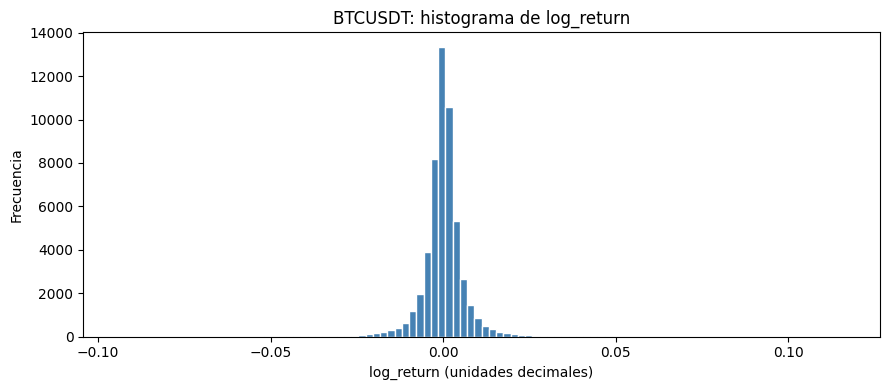

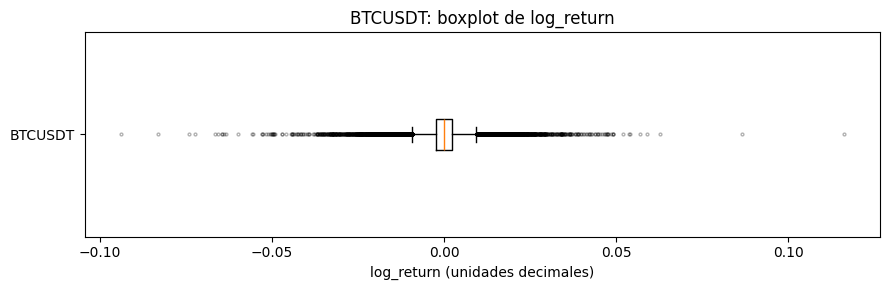

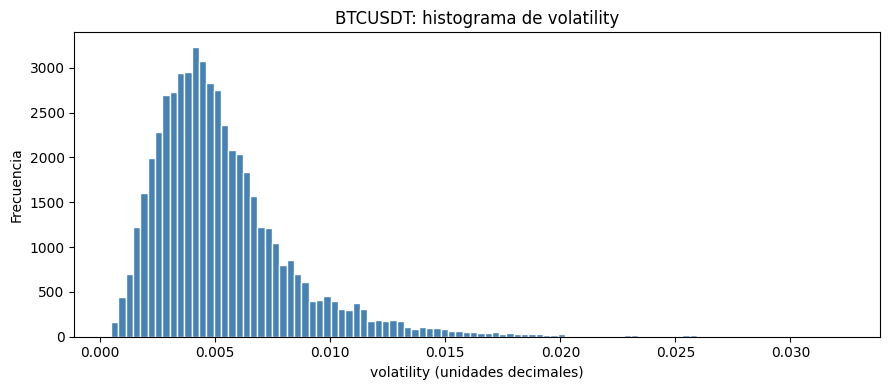

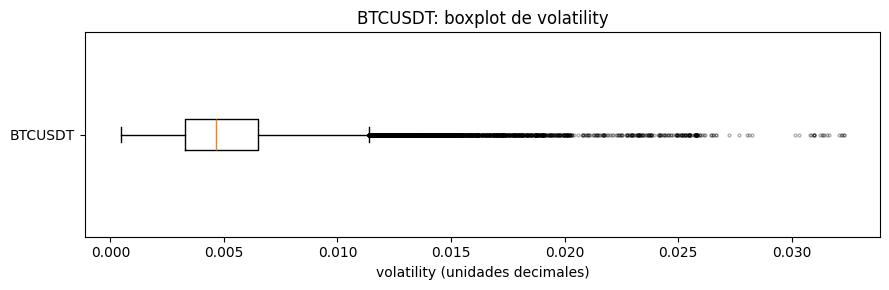

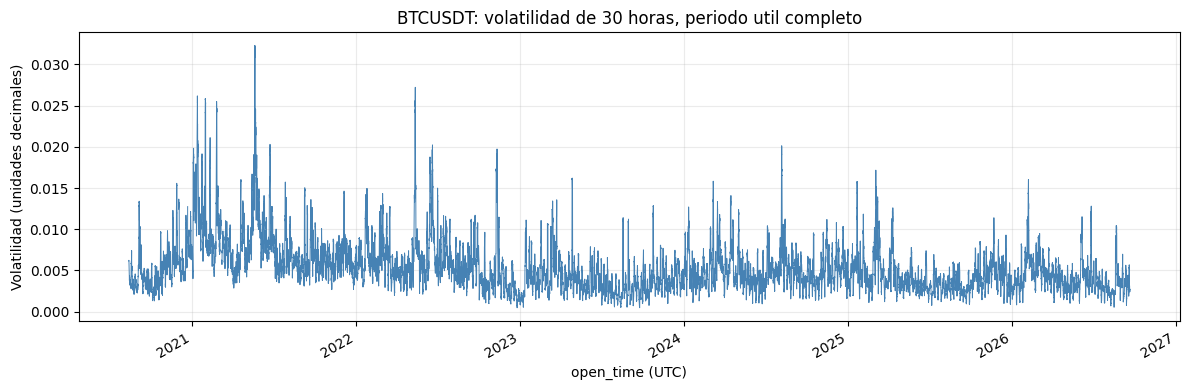

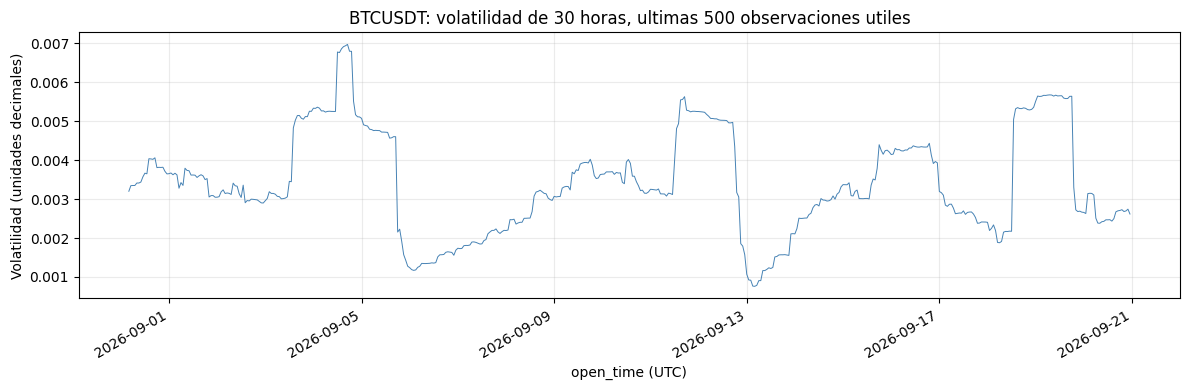

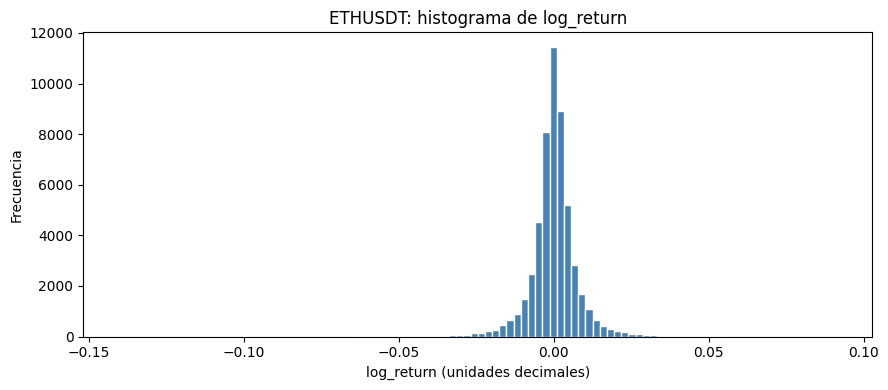

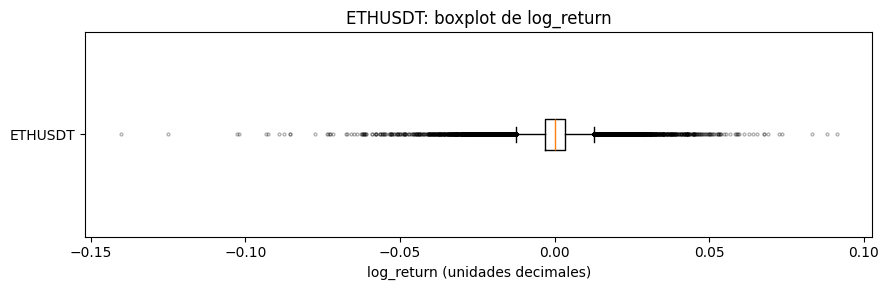

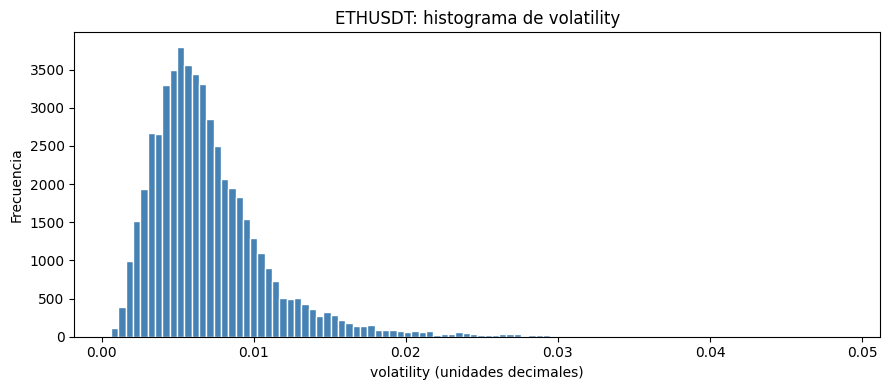

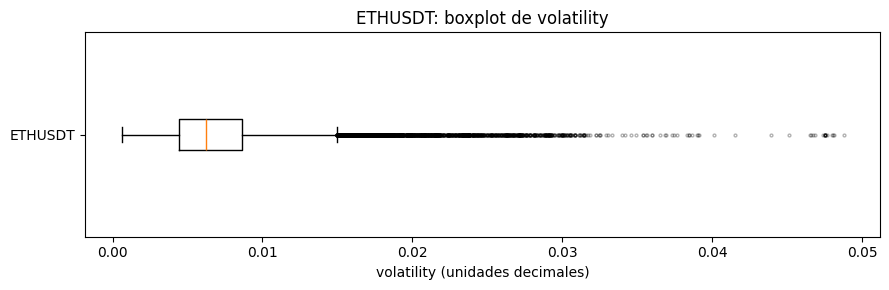

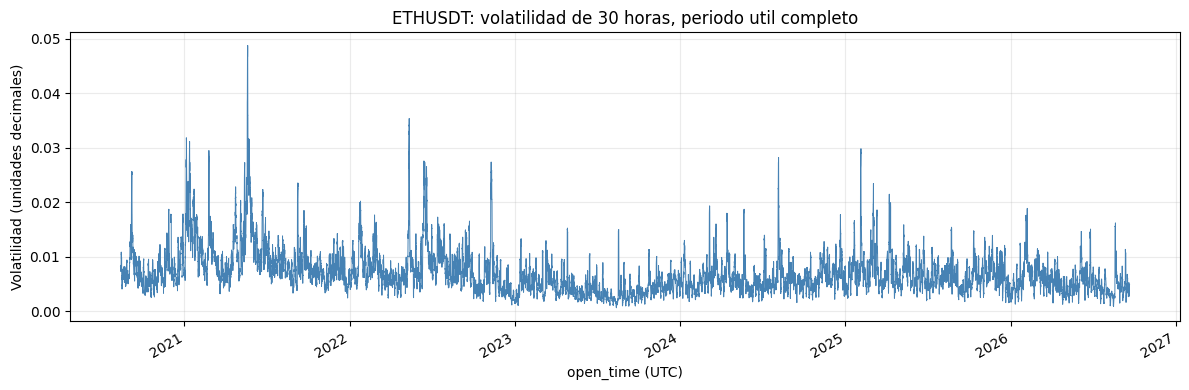

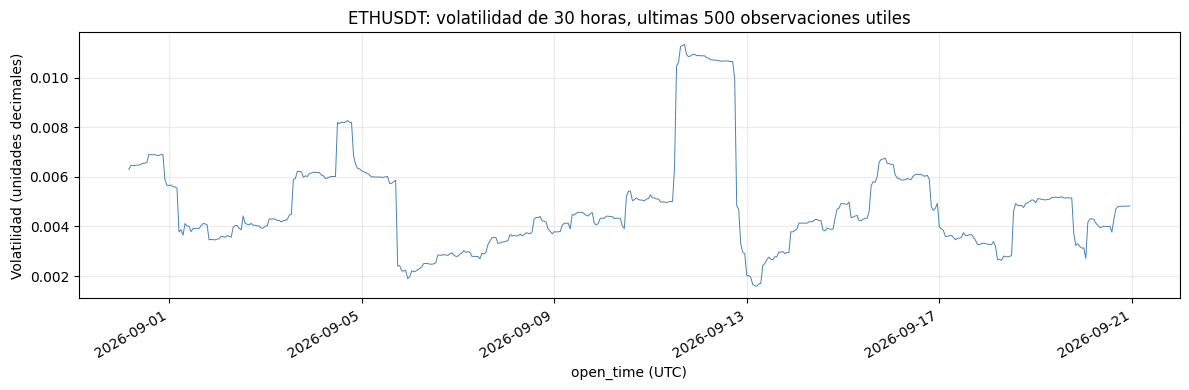

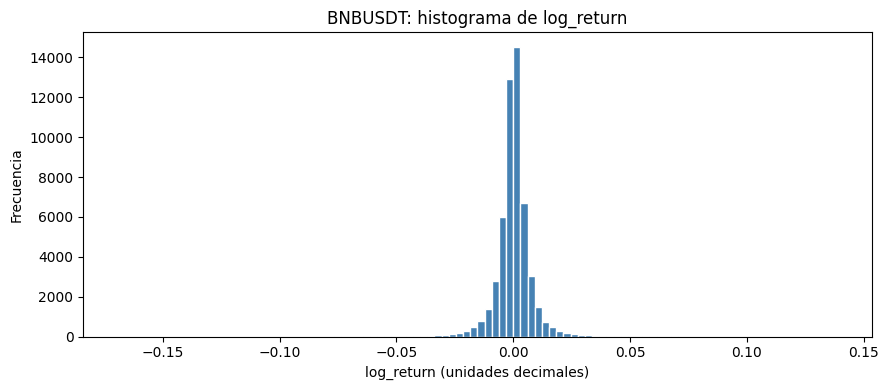

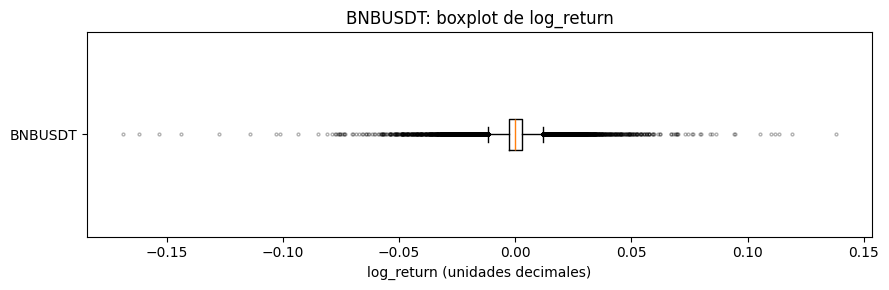

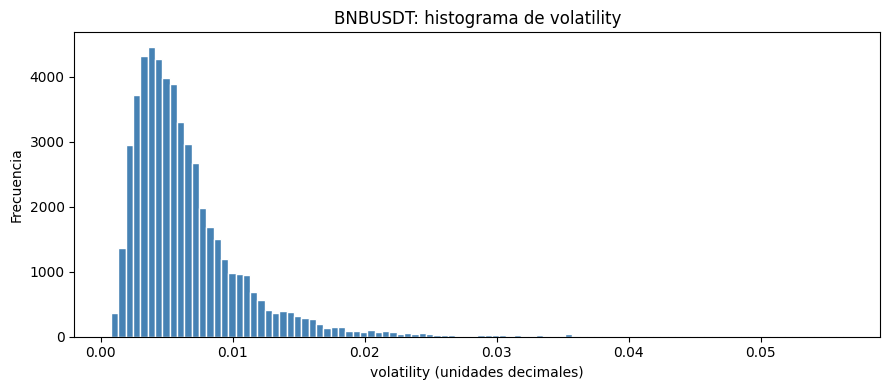

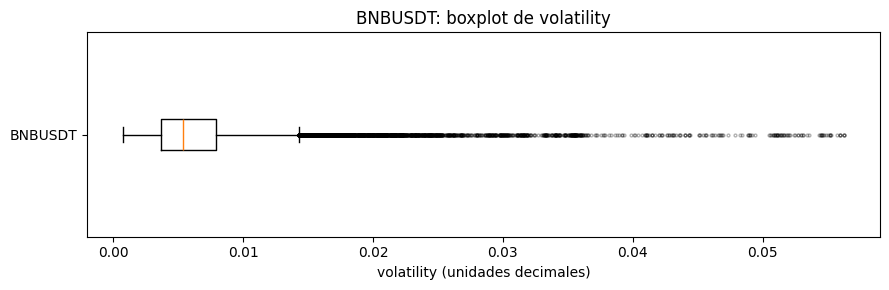

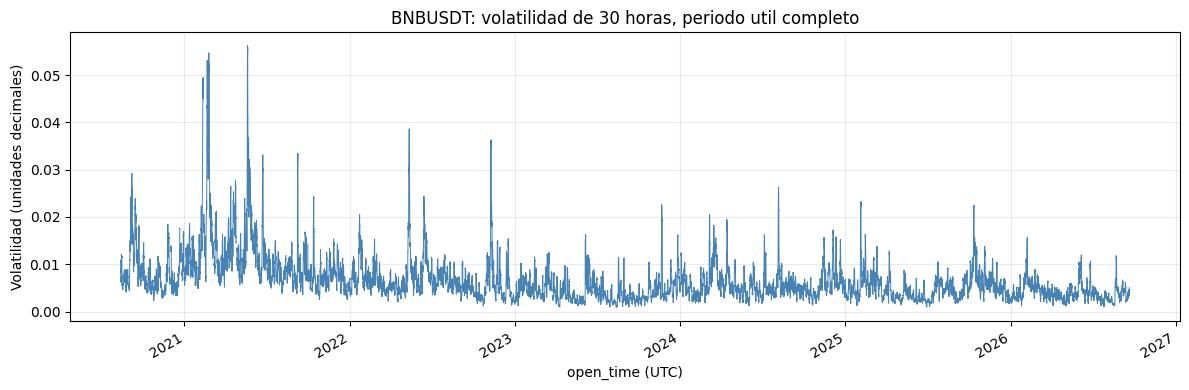

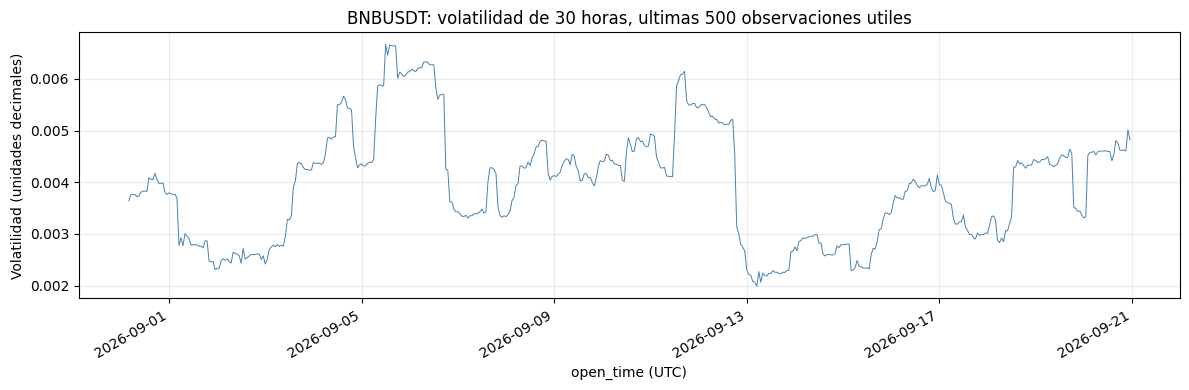

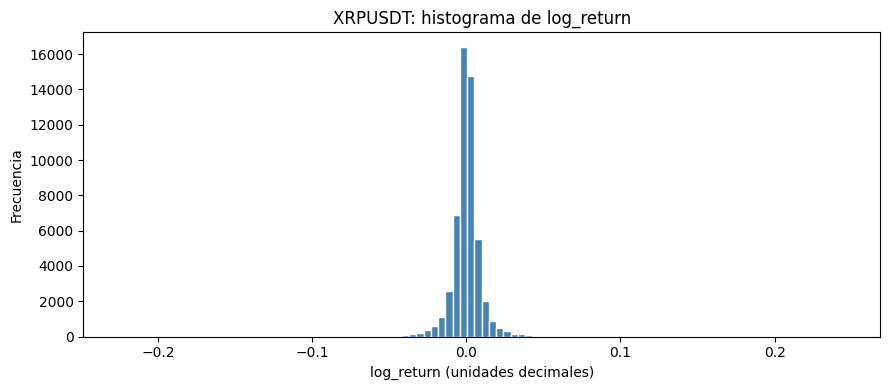

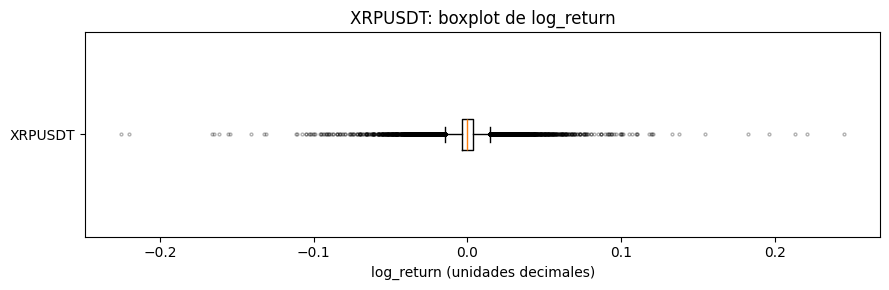

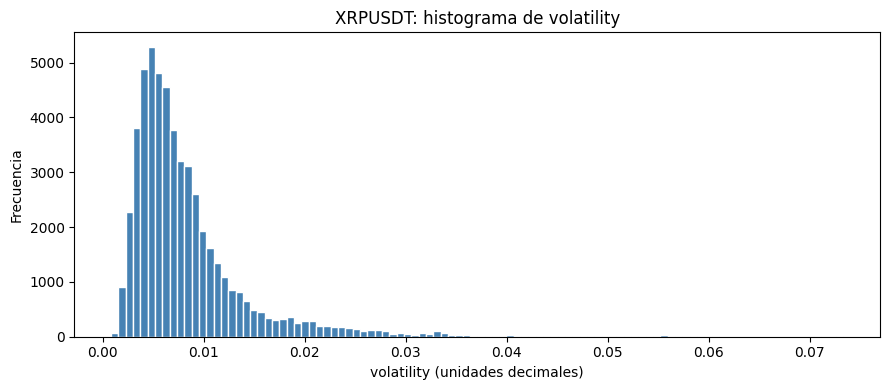

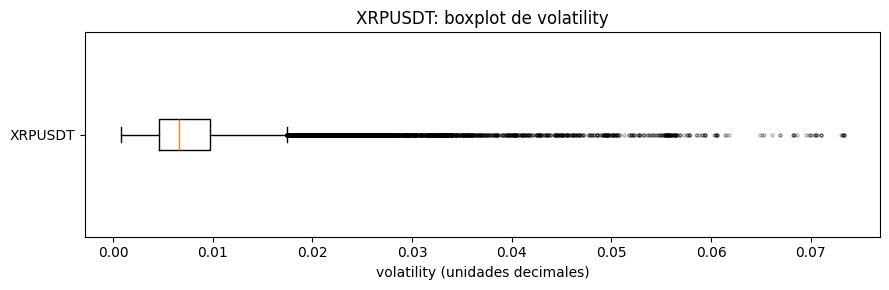

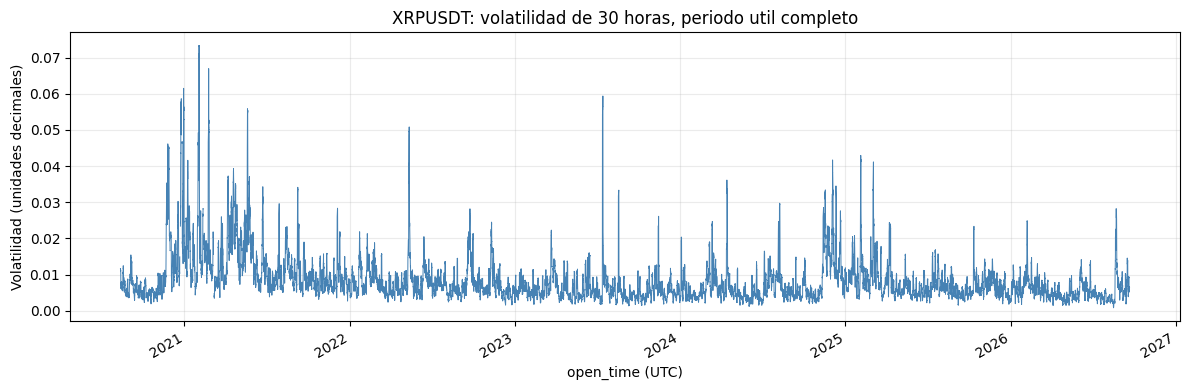

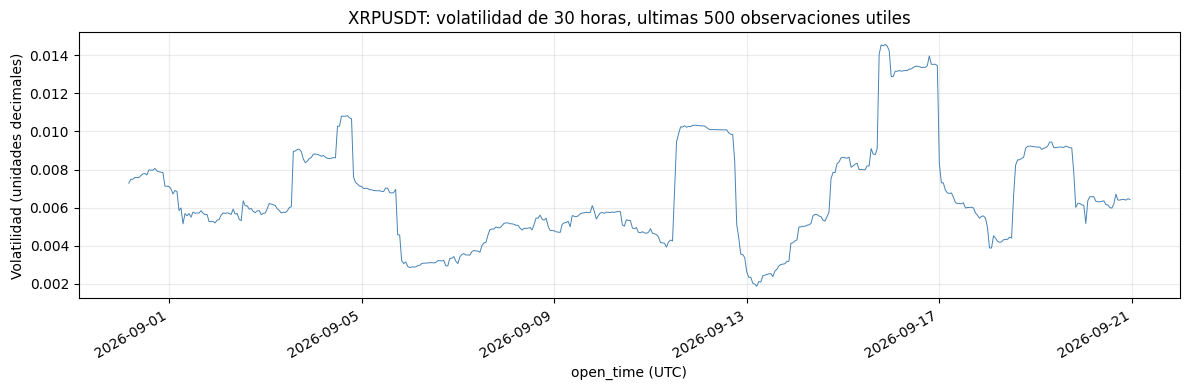

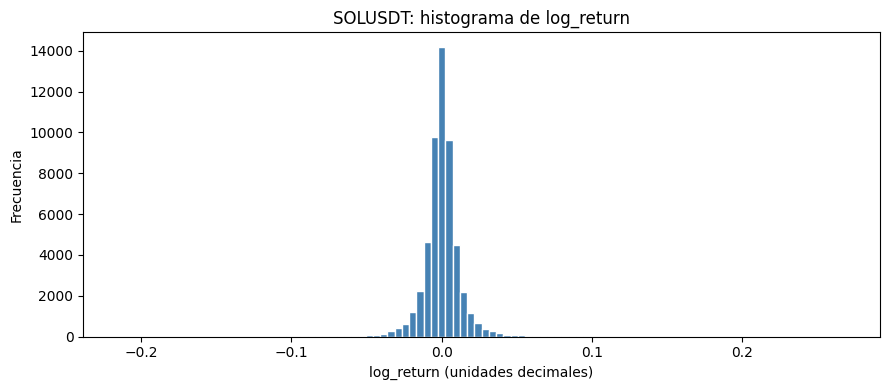

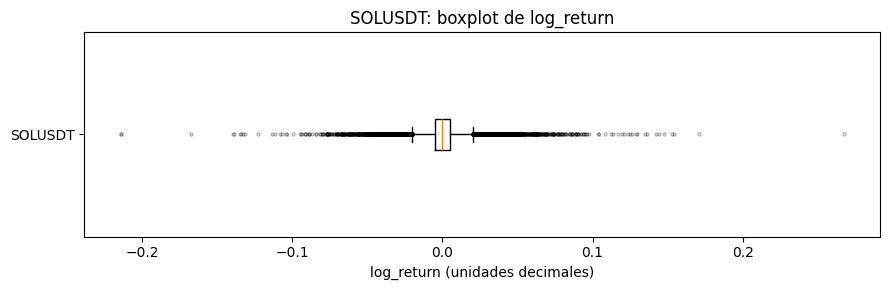

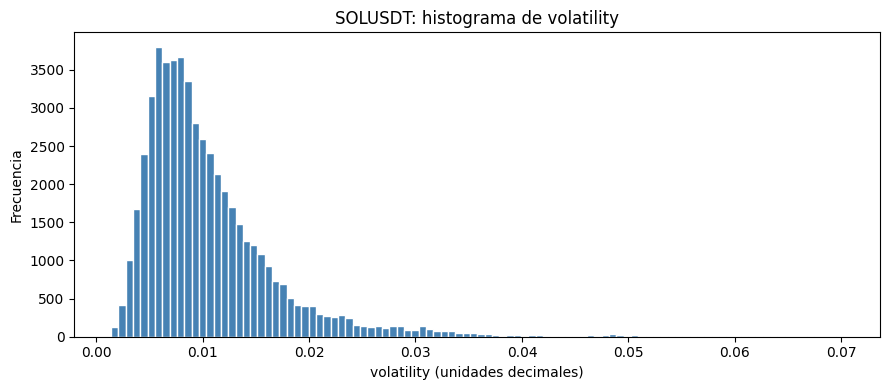

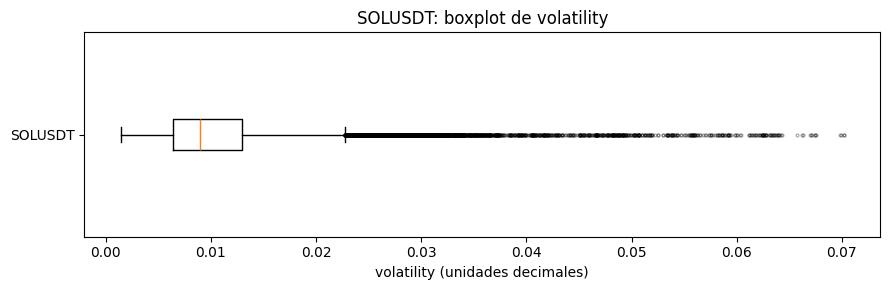

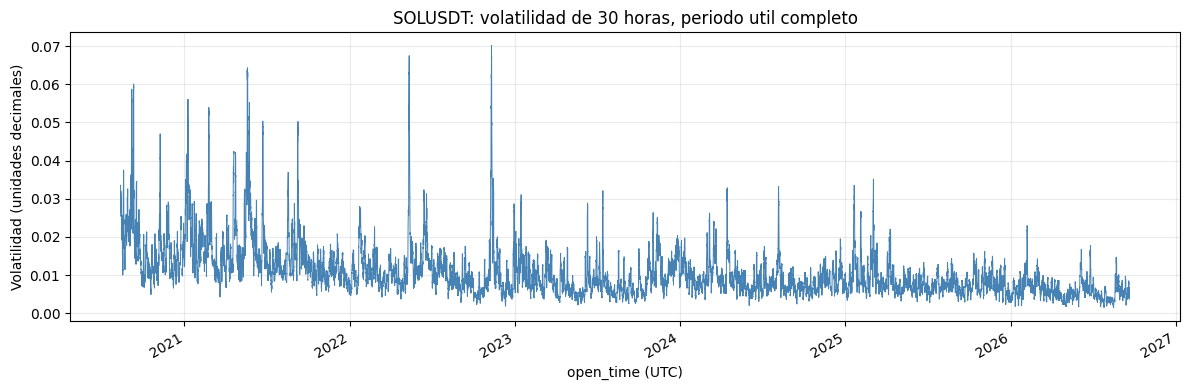

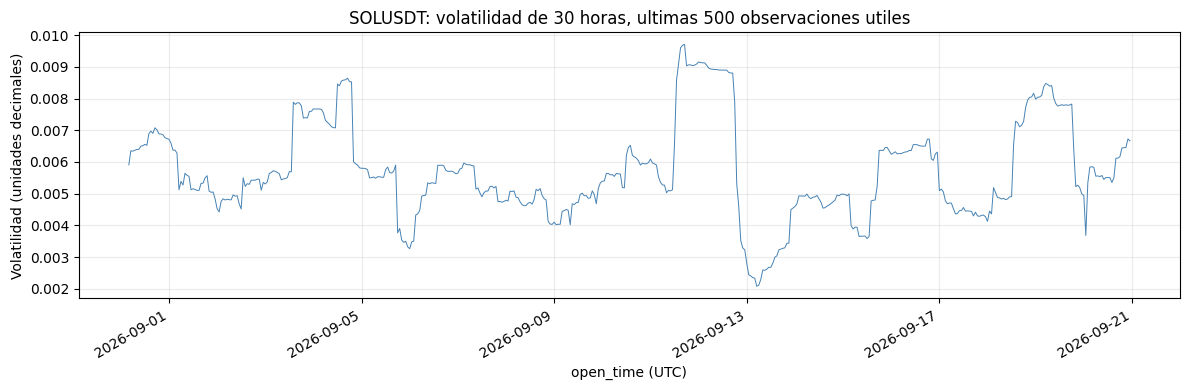

In [7]:
FIGURES_DIR = Path("notebooks/figs")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
eda_figure_paths = []

def save_eda_figure(fig, filename):
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    eda_figure_paths.append(path)
    plt.show()
    plt.close(fig)

for symbol in SYMBOLS:
    asset = eda_data.loc[eda_data.symbol.eq(symbol)].sort_values("open_time")
    for variable in ["log_return", "volatility"]:
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.hist(asset[variable], bins=100, color="steelblue", edgecolor="white")
        ax.set(title=f"{symbol}: histograma de {variable}",
               xlabel=f"{variable} (unidades decimales)", ylabel="Frecuencia")
        save_eda_figure(fig, f"eda_{symbol}_{variable}_histogram.png")

        fig, ax = plt.subplots(figsize=(9, 3))
        ax.boxplot(asset[variable].to_numpy(), vert=False, showfliers=True,
                   flierprops={"markersize": 2, "alpha": .3})
        ax.set(title=f"{symbol}: boxplot de {variable}",
               xlabel=f"{variable} (unidades decimales)", yticks=[1], yticklabels=[symbol])
        save_eda_figure(fig, f"eda_{symbol}_{variable}_boxplot.png")

    for suffix, view, title in [
        ("full", asset, "periodo util completo"),
        ("last500", asset.tail(500), "ultimas 500 observaciones utiles"),
    ]:
        fig, ax = plt.subplots(figsize=(12, 4))
        for _, segment in view.groupby("segment_id", sort=False):
            ax.plot(segment.open_time, segment.volatility,
                    color="steelblue", linewidth=.7)
        ax.set(title=f"{symbol}: volatilidad de 30 horas, {title}",
               xlabel="open_time (UTC)", ylabel="Volatilidad (unidades decimales)")
        ax.grid(alpha=.25)
        fig.autofmt_xdate()
        save_eda_figure(fig, f"eda_{symbol}_volatility_time_{suffix}.png")


### 2.4.1 Autocorrelación hasta 48 horas

Para cada activo calculamos la ACF de `log_return`, `log_return` al cuadrado y `volatility`. Como existen discontinuidades, solo incluimos productos de observaciones pertenecientes al mismo segmento continuo:

$$\widehat\rho(k)=\frac{\sum_s\sum_{t=k+1}^{n_s}(x_{s,t}-\bar x)(x_{s,t-k}-\bar x)}{\sum_s\sum_{t=1}^{n_s}(x_{s,t}-\bar x)^2},\qquad k=0,\ldots,48.$$

Aqui $s$ identifica un segmento y $\bar x$ es la media de la variable para ese activo en el conjunto util. Es la ACF con denominador fijo (sin ajuste por el numero de pares), extendida a segmentos; no concatenamos extremos separados por huecos. Cada rezago representa horas consecutivas y se reporta el numero de pares utilizados. No se presentan bandas de significancia basadas en el supuesto de observaciones independientes.

La persistencia de una volatilidad movil incluye un efecto mecanico: ventanas consecutivas de 30 retornos comparten 29 observaciones. Por ello tambien examinamos los retornos al cuadrado y los rezagos superiores a la ventana.

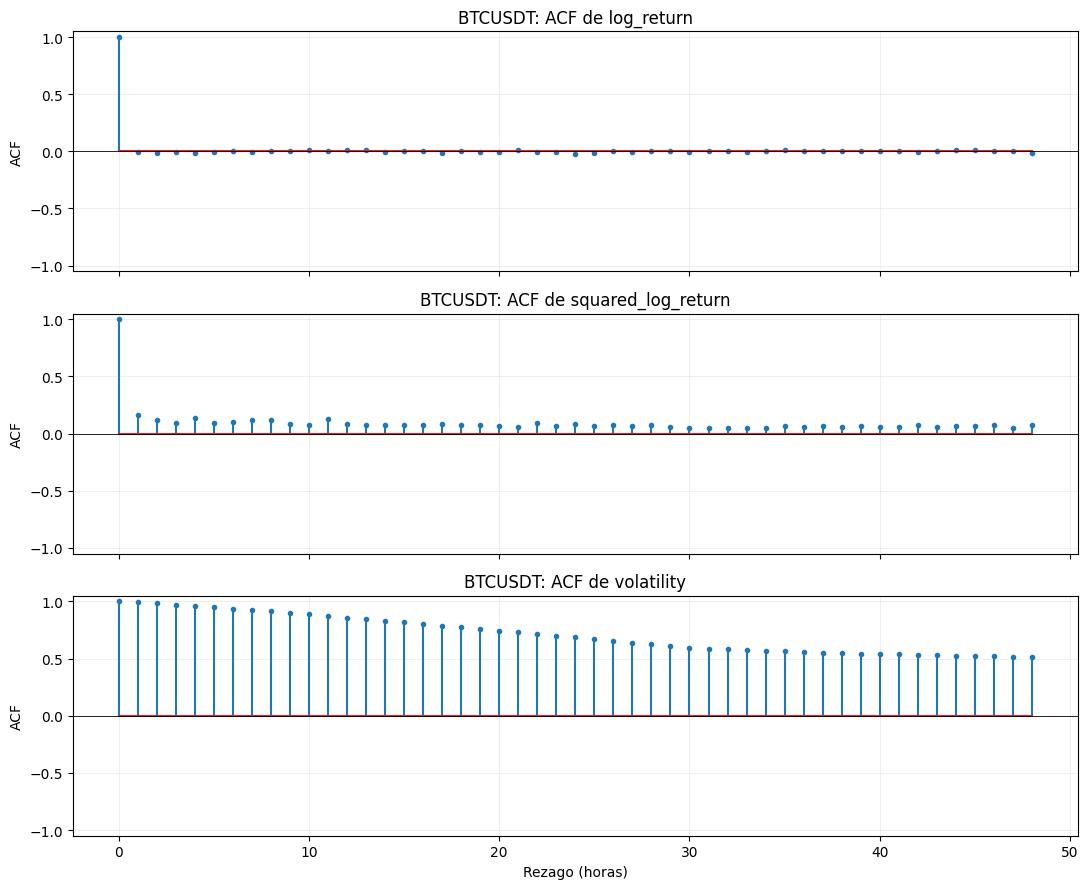

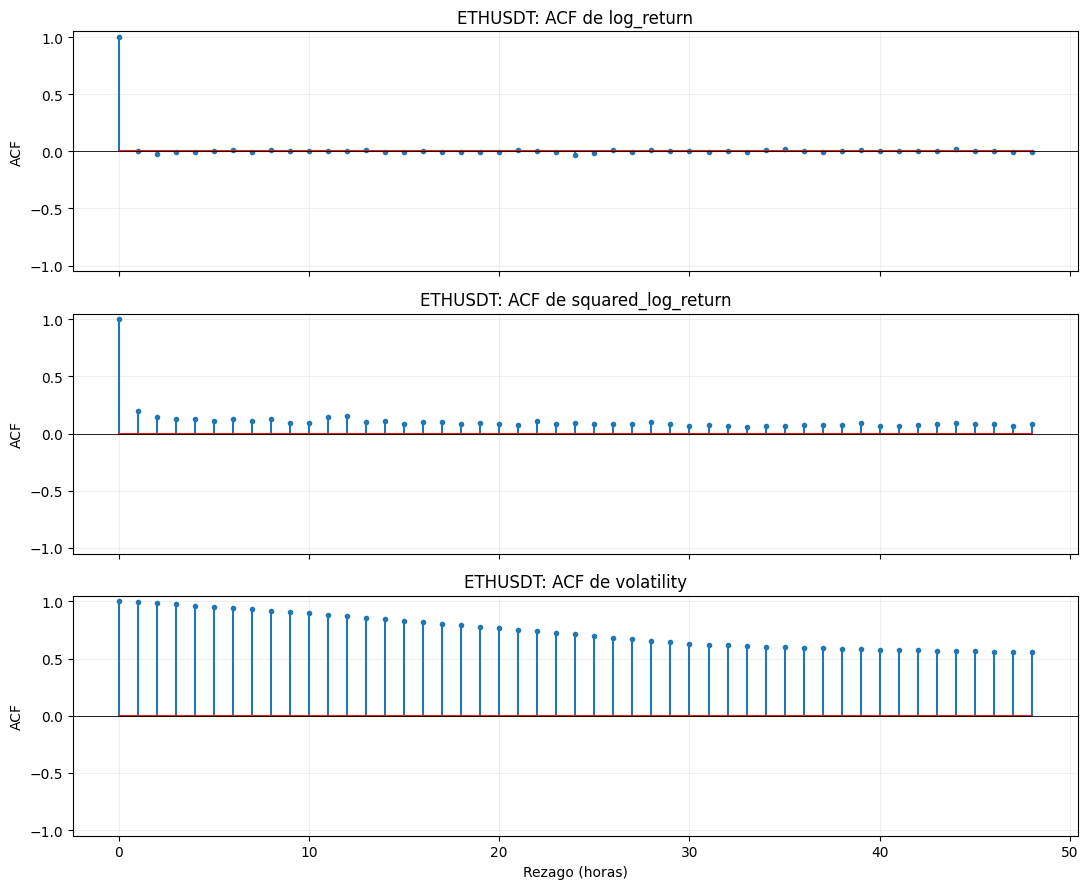

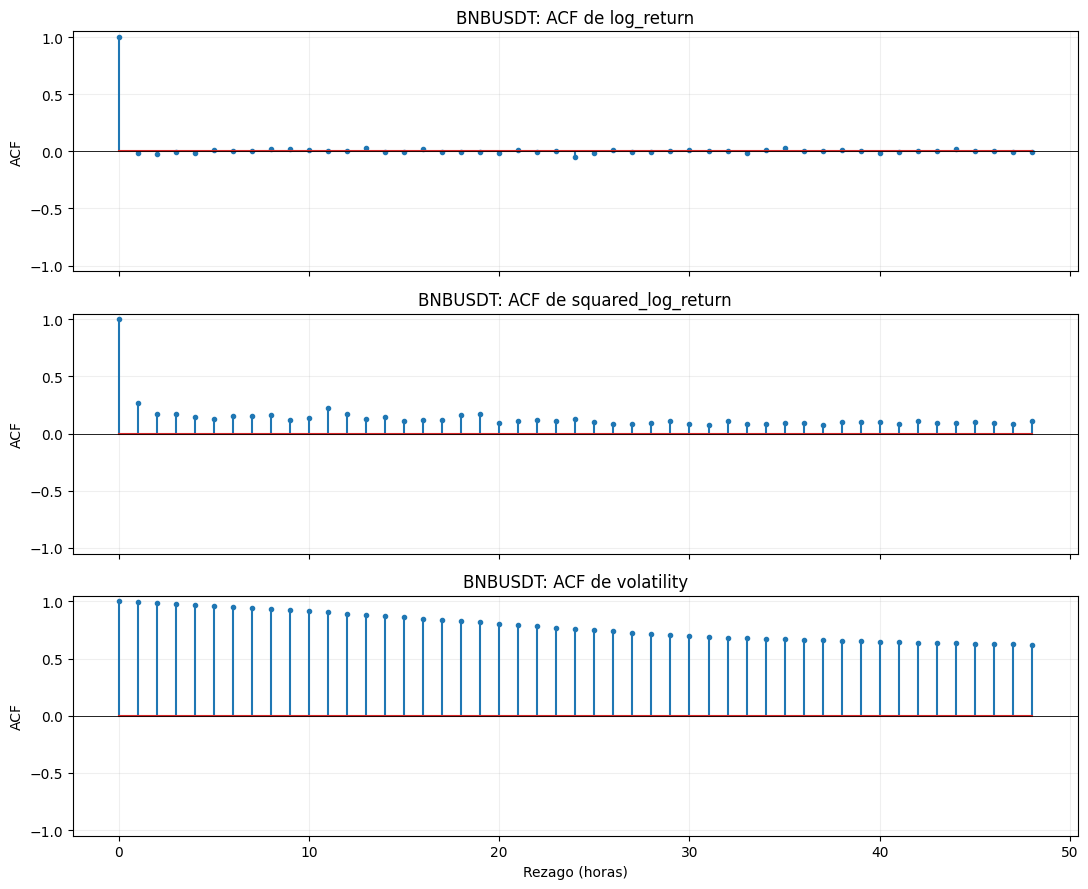

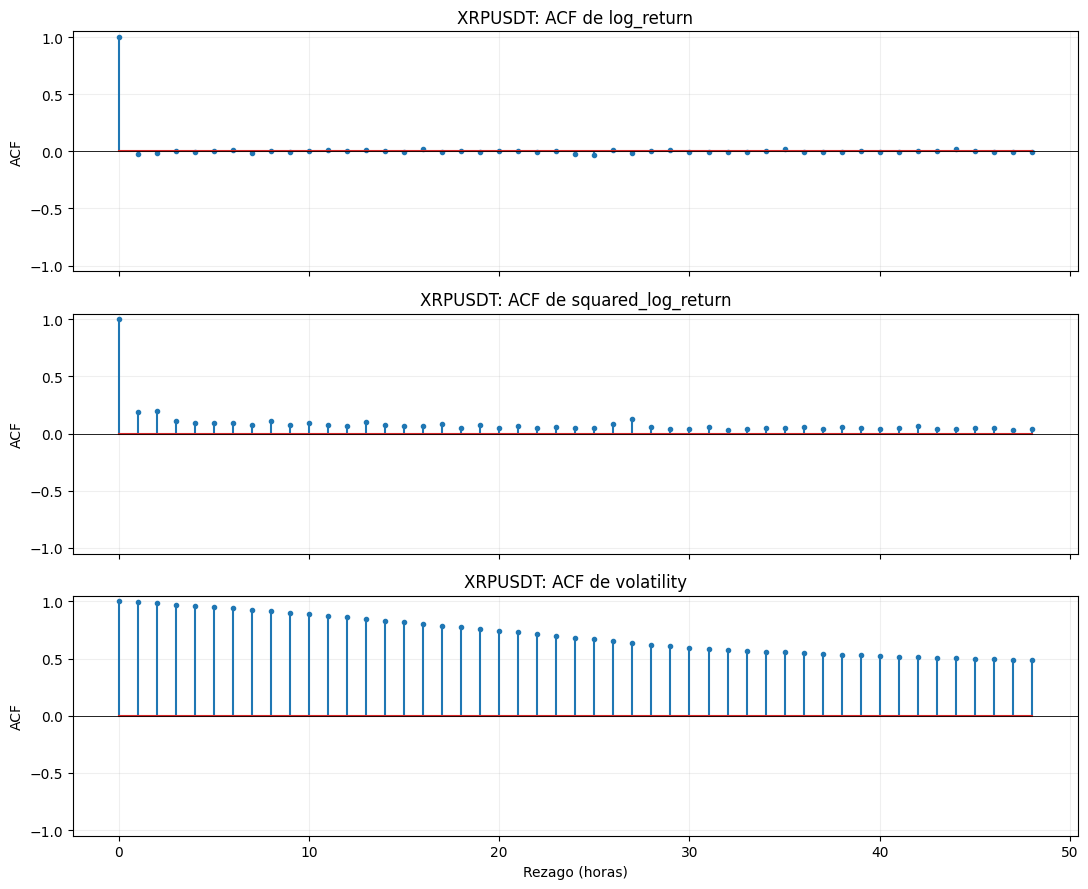

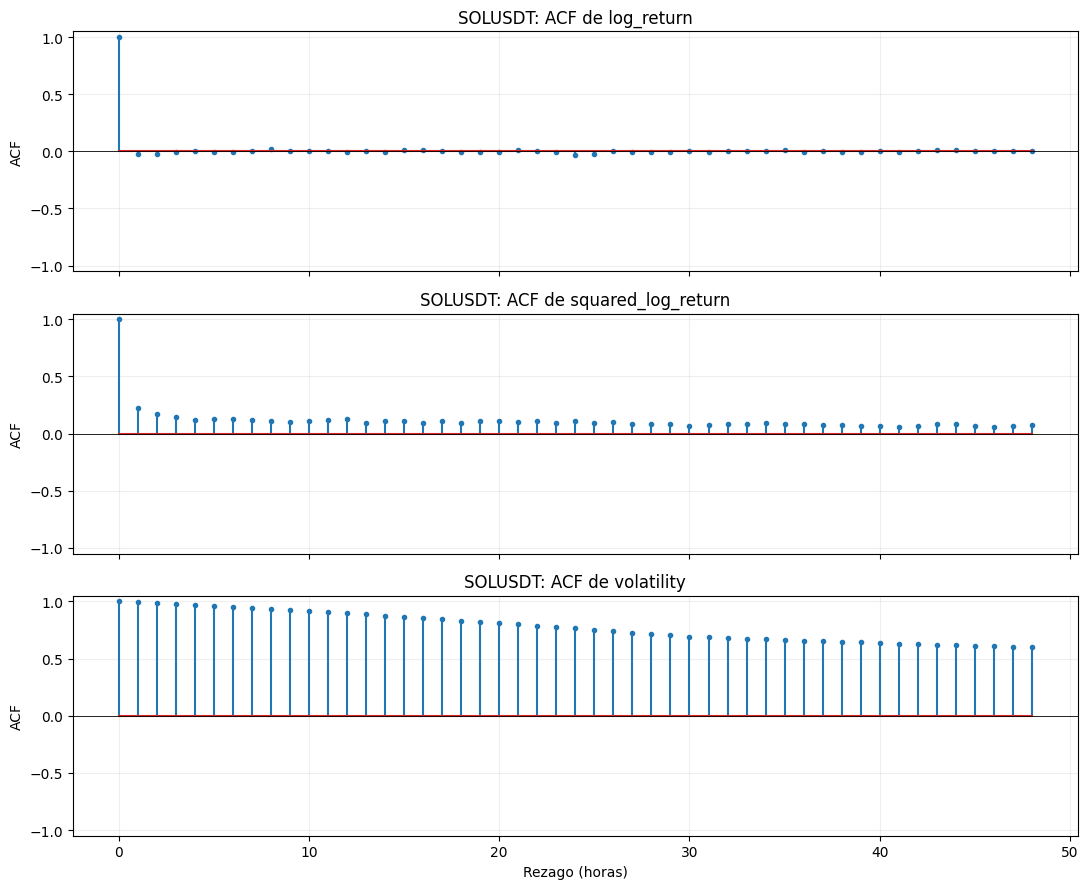

ACF de volatility en rezagos seleccionados:


lag,1,6,12,24,48
symbol,,,,,
BTCUSDT,0.992150,0.937496,0.858923,0.685541,0.512702
ETHUSDT,0.992646,0.942985,0.871116,0.711353,0.553773
BNBUSDT,0.994176,0.953842,0.894428,0.760582,0.620270
XRPUSDT,0.992395,0.938520,0.859920,0.683044,0.483882
SOLUSDT,0.994264,0.954372,0.896972,0.764200,0.601369


ACF completa y numero de pares por activo y variable (rezagos 0 a 48):
BTCUSDT


acf                                    pairs  \
variable log_return squared_log_return volatility log_return   
lag                                                            
0          1.000000           1.000000   1.000000    53212.0   
1         -0.009137           0.159496   0.992150    53201.0   
2         -0.013118           0.121566   0.982552    53190.0   
3         -0.001490           0.092039   0.972054    53179.0   
4         -0.013528           0.132635   0.960995    53168.0   
5         -0.002265           0.092607   0.949397    53157.0   
6          0.006546           0.103249   0.937496    53146.0   
7         -0.007176           0.117155   0.925245    53135.0   
8          0.006779           0.118241   0.912591    53124.0   
9          0.005783           0.080222   0.899525    53113.0   
10         0.008074           0.073354   0.886228    53102.0   
11         0.006826           0.127295   0.872770    53091.0   
12         0.010912           0.083692   0.858923    53080.0   
13         0.012958           0.076921   0.844967    53069.0   
14        -0.009809           0.073533   0.830837    53058.0   
15        -0.001273           0.073211   0.816625    53047.0   
16         0.005250           0.073026   0.802381    53036.0   
17        -0.013332           0.080030   0.788053    53025.0   
18         0.005947           0.073524   0.773606    53014.0   
19        -0.008206           0.075167   0.759159    53003.0   
20        -0.002088           0.066180   0.744688    52992.0   
21         0.007647           0.057917   0.730150    52981.0   
22        -0.003405           0.092043   0.715460    52970.0   
23        -0.006951           0.065446   0.700549    52959.0   
24        -0.023383           0.083325   0.685541    52948.0   
25        -0.015098           0.066563   0.670212    52937.0   
26        -0.000675           0.074164   0.654704    52926.0   
27        -0.006481           0.061609   0.639196    52915.0   
28         0.006628           0.076800   0.623749    52904.0   
29        -0.000114           0.059908   0.608542    52893.0   
30        -0.002617           0.049345   0.594075    52882.0   
31        -0.000562           0.052641   0.586583    52871.0   
32         0.004768           0.050474   0.580041    52860.0   
33        -0.007317           0.049507   0.573990    52849.0   
34        -0.000477           0.051563   0.568263    52838.0   
35         0.012921           0.065488   0.562861    52827.0   
36         0.006408           0.060428   0.557701    52816.0   
37         0.002678           0.070001   0.552843    52805.0   
38         0.002396           0.054473   0.548188    52794.0   
39         0.000764           0.066829   0.543917    52783.0   
40        -0.000056           0.053351   0.539869    52772.0   
41         0.004059           0.054333   0.536018    52761.0   
42        -0.002993           0.076354   0.532556    52750.0   
43         0.000647           0.060042   0.529162    52739.0   
44         0.014562           0.064707   0.525872    52728.0   
45         0.007421           0.065973   0.522600    52717.0   
46         0.002513           0.074386   0.519228    52706.0   
47        -0.001182           0.048618   0.515914    52695.0   
48        -0.012171           0.073622   0.512702    52684.0   

                                        
variable squared_log_return volatility  
lag                                     
0                   53212.0    53212.0  
1                   53201.0    53201.0  
2                   53190.0    53190.0  
3                   53179.0    53179.0  
4                   53168.0    53168.0  
5                   53157.0    53157.0  
6                   53146.0    53146.0  
7                   53135.0    53135.0  
8                   53124.0    53124.0  
9                   53113.0    53113.0  
10                  53102.0    53102.0  
11                  53091.0    53091.0  
12                  53080.0    53080.0  
13                  53069.0    

ETHUSDT


...

XRPUSDT


acf                                    pairs  \
variable log_return squared_log_return volatility log_return   
lag                                                            
0          1.000000           1.000000   1.000000    53212.0   
1         -0.019988           0.184699   0.992395    53201.0   
2         -0.018593           0.196273   0.983115    53190.0   
3          0.001222           0.106419   0.972679    53179.0   
4         -0.010178           0.095176   0.961676    53168.0   
5          0.001472           0.089200   0.950315    53157.0   
6          0.014165           0.095441   0.938520    53146.0   
7         -0.010678           0.077440   0.926312    53135.0   
8          0.006051           0.105726   0.913750    53124.0   
9         -0.003917           0.076937   0.900728    53113.0   
10         0.002059           0.096203   0.887451    53102.0   
11         0.007448           0.071899   0.873760    53091.0   
12         0.006316           0.067869   0.859920    53080.0   
13         0.010806           0.102432   0.845893    53069.0   
14        -0.000268           0.076455   0.831689    53058.0   
15        -0.004805           0.068985   0.817279    53047.0   
16         0.017469           0.068665   0.802714    53036.0   
17        -0.002663           0.080826   0.788151    53025.0   
18         0.005502           0.049784   0.773356    53014.0   
19        -0.001754           0.074705   0.758558    53003.0   
20         0.002826           0.050771   0.743482    52992.0   
21         0.005002           0.069486   0.728489    52981.0   
22        -0.004340           0.048245   0.713418    52970.0   
23        -0.000924           0.058678   0.698305    52959.0   
24        -0.026721           0.052216   0.683044    52948.0   
25        -0.029206           0.044712   0.667763    52937.0   
26         0.008937           0.081287   0.652584    52926.0   
27        -0.013194           0.122977   0.637398    52915.0   
28         0.006753           0.057582   0.621962    52904.0   
29         0.007690           0.042644   0.606788    52893.0   
30        -0.004093           0.040632   0.592349    52882.0   
31        -0.003207           0.056586   0.583484    52871.0   
32        -0.003422           0.034554   0.575393    52860.0   
33        -0.009686           0.036312   0.568019    52849.0   
34         0.003470           0.047934   0.561001    52838.0   
35         0.016383           0.046332   0.554223    52827.0   
36        -0.005610           0.053661   0.547578    52816.0   
37        -0.005140           0.039758   0.541218    52805.0   
38        -0.008447           0.056440   0.535112    52794.0   
39         0.005354           0.052356   0.529272    52783.0   
40        -0.005495           0.041073   0.523512    52772.0   
41        -0.003444           0.049220   0.518064    52761.0   
42         0.005099           0.061609   0.512707    52750.0   
43        -0.000004           0.039793   0.507375    52739.0   
44         0.016853           0.041174   0.502361    52728.0   
45         0.005162           0.049549   0.497485    52717.0   
46        -0.003386           0.049571   0.492718    52706.0   
47        -0.005970           0.027357   0.488103    52695.0   
48        -0.007872           0.038177   0.483882    52684.0   

                                        
variable squared_log_return volatility  
lag                                     
0                   53212.0    53212.0  
1                   53201.0    53201.0  
2                   53190.0    53190.0  
3                   53179.0    53179.0  
4                   53168.0    53168.0  
5                   53157.0    53157.0  
6                   53146.0    53146.0  
7                   53135.0    53135.0  
8                   53124.0    53124.0  
9                   53113.0    53113.0  
10                  53102.0    53102.0  
11                  53091.0    53091.0  
12                  53080.0    53080.0  
13                  53069.0    

SOLUSDT


acf                                    pairs  \
variable log_return squared_log_return volatility log_return   
lag                                                            
0          1.000000           1.000000   1.000000    53212.0   
1         -0.023500           0.225848   0.994264    53201.0   
2         -0.023919           0.169729   0.987346    53190.0   
3         -0.004818           0.141887   0.979705    53179.0   
4          0.003482           0.114764   0.971526    53168.0   
5         -0.007364           0.129183   0.963111    53157.0   
6         -0.007609           0.124660   0.954372    53146.0   
7         -0.001015           0.122379   0.945337    53135.0   
8          0.017640           0.107665   0.936000    53124.0   
9         -0.000757           0.101229   0.926555    53113.0   
10         0.002233           0.108703   0.916884    53102.0   
11         0.007085           0.117972   0.907042    53091.0   
12        -0.008725           0.130037   0.896972    53080.0   
13         0.003481           0.095444   0.886650    53069.0   
14        -0.005118           0.106036   0.876178    53058.0   
15         0.007825           0.113109   0.865508    53047.0   
16         0.013863           0.094592   0.854654    53036.0   
17         0.001690           0.108076   0.843670    53025.0   
18        -0.008158           0.094398   0.832516    53014.0   
19        -0.006343           0.106041   0.821408    53003.0   
20        -0.003493           0.109744   0.810253    52992.0   
21         0.013741           0.101082   0.798966    52981.0   
22         0.004434           0.111946   0.787608    52970.0   
23        -0.003928           0.094140   0.775953    52959.0   
24        -0.030517           0.113619   0.764200    52948.0   
25        -0.019364           0.088317   0.752205    52937.0   
26         0.002713           0.097510   0.740117    52926.0   
27        -0.006979           0.081376   0.727876    52915.0   
28        -0.004771           0.082328   0.715719    52904.0   
29        -0.009593           0.087716   0.703814    52893.0   
30        -0.001329           0.064443   0.692358    52882.0   
31        -0.002474           0.072583   0.685751    52871.0   
32         0.005379           0.080298   0.679650    52860.0   
33         0.001460           0.081277   0.673793    52849.0   
34        -0.000394           0.090339   0.668176    52838.0   
35         0.014888           0.081217   0.662538    52827.0   
36        -0.001954           0.086484   0.657077    52816.0   
37         0.004228           0.073177   0.651716    52805.0   
38        -0.002869           0.072605   0.646528    52794.0   
39        -0.003767           0.065329   0.641424    52783.0   
40         0.004550           0.063099   0.636461    52772.0   
41        -0.007615           0.061138   0.631624    52761.0   
42         0.004504           0.065955   0.626963    52750.0   
43         0.014619           0.082327   0.622428    52739.0   
44         0.009082           0.085438   0.618008    52728.0   
45         0.001819           0.064879   0.613664    52717.0   
46         0.001658           0.061250   0.609432    52706.0   
47         0.002981           0.066412   0.605369    52695.0   
48         0.004985           0.077604   0.601369    52684.0   

                                        
variable squared_log_return volatility  
lag                                     
0                   53212.0    53212.0  
1                   53201.0    53201.0  
2                   53190.0    53190.0  
3                   53179.0    53179.0  
4                   53168.0    53168.0  
5                   53157.0    53157.0  
6                   53146.0    53146.0  
7                   53135.0    53135.0  
8                   53124.0    53124.0  
9                   53113.0    53113.0  
10                  53102.0    53102.0  
11                  53091.0    53091.0  
12                  53080.0    53080.0  
13                  53069.0    

Figuras generadas: 35


In [8]:
ACF_MAX_LAG = 48
ACF_REPORT_LAGS = [1, 6, 12, 24, 48]

def segmented_acf(frame, variable, max_lag=48):
    mean = frame[variable].mean()
    segments = [g[variable].to_numpy(dtype=float) - mean
                for _, g in frame.groupby("segment_id", sort=False)]
    denominator = sum(np.dot(x, x) for x in segments)
    assert denominator > 0, "ACF no definida para una serie constante"
    values, pairs = [], []
    for lag in range(max_lag + 1):
        if lag == 0:
            values.append(1.0)
            pairs.append(sum(len(x) for x in segments))
        else:
            count = sum(max(len(x) - lag, 0) for x in segments)
            numerator = sum(np.dot(x[lag:], x[:-lag])
                            for x in segments if len(x) > lag)
            values.append(numerator / denominator if count else np.nan)
            pairs.append(count)
    return np.asarray(values), np.asarray(pairs)

acf_rows = []
for symbol in SYMBOLS:
    asset = eda_data.loc[eda_data.symbol.eq(symbol)].copy()
    asset["squared_log_return"] = asset.log_return.pow(2)
    for _, segment in asset.groupby("segment_id"):
        assert segment.open_time.diff().dropna().eq(pd.Timedelta(hours=1)).all()
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    for ax, variable in zip(axes, ["log_return", "squared_log_return", "volatility"]):
        values, pairs = segmented_acf(asset, variable, ACF_MAX_LAG)
        for lag, value, count in zip(range(ACF_MAX_LAG + 1), values, pairs):
            acf_rows.append({"symbol": symbol, "variable": variable,
                             "lag": lag, "acf": value, "pairs": count})
        ax.stem(range(ACF_MAX_LAG + 1), values, markerfmt=".")
        ax.axhline(0, color="black", linewidth=.6)
        ax.set(title=f"{symbol}: ACF de {variable}", ylabel="ACF", ylim=(-1.05, 1.05))
        ax.grid(alpha=.2)
    axes[-1].set_xlabel("Rezago (horas)")
    save_eda_figure(fig, f"eda_{symbol}_acf_returns_squared_returns_volatility_48h.png")

eda_acf = pd.DataFrame(acf_rows)
volatility_acf_summary = (
    eda_acf.loc[eda_acf.variable.eq("volatility") & eda_acf.lag.isin(ACF_REPORT_LAGS)]
    .pivot(index="symbol", columns="lag", values="acf").reindex(SYMBOLS)
)
print("ACF de volatility en rezagos seleccionados:")
display(volatility_acf_summary)
print("ACF completa y numero de pares por activo y variable (rezagos 0 a 48):")
for symbol in SYMBOLS:
    print(symbol)
    display(eda_acf.loc[eda_acf.symbol.eq(symbol)]
            .pivot(index="lag", columns="variable", values=["acf", "pairs"]))
print("Figuras generadas:", len(eda_figure_paths))
assert len(eda_figure_paths) == 35
assert all(path.is_file() and path.stat().st_size > 0 for path in eda_figure_paths)


### 2.4.2 Interpretación de los resultados

**Retornos cerca de cero.** Las medias horarias van de 0,0000236 (XRP) a 0,0000604 (SOL), frente a desviaciones estándar de 0,00619 a 0,01273. La media es inferior al 0,8% de la desviación estándar en cada activo: los retornos parecen centrados cerca de cero en terminos descriptivos, sin que esto constituya una prueba formal de media poblacional nula.

**Colas pesadas y asimetria.** El exceso de curtosis es BTC 16,12; ETH 14,63; BNB 30,16; XRP 44,41; SOL 20,26. Estos valores elevados son compatibles con colas pesadas frente a una normal y extremos, conservados en histogramas y boxplots. XRP presenta el mayor exceso de curtosis. La asimetria es negativa para BTC (-0,22), ETH (-0,51) y BNB (-0,52), y positiva para XRP (0,19) y SOL (0,28). Estas medidas describen la muestra y no identifican por si solas una distribucion teorica.

**Diferencias entre activos.** La volatilidad media aumenta en el orden BTC (0,00534), BNB (0,00659), ETH (0,00705), XRP (0,00845) y SOL (0,01071). SOL tiene aproximadamente el doble de volatilidad media que BTC. La media supera a la mediana en los cinco activos, consistente con distribuciones extendidas hacia valores altos. XRP registra el mayor maximo de volatilidad (0,07333), seguido de SOL (0,07019); BTC tiene el menor (0,03230). Los precios nominales de `close` estan en USDT por unidad y no permiten comparar directamente el riesgo entre activos.

**Persistencia temporal.** La ACF de `volatility` al rezago 1 esta entre 0,992 y 0,994; al rezago 24, entre 0,683 y 0,764; y al rezago 48, entre 0,484 y 0,620. BNB (0,620) y SOL (0,601) presentan mayor persistencia a 48 horas, y XRP la menor (0,484). Parte de la dependencia de corto plazo es mecanica: las ventanas consecutivas comparten 29 de 30 retornos. A 48 horas ya no hay ese solapamiento directo; la asociacion es compatible con persistencia mas alla de la ventana, aunque tambien puede reflejar cambios de regimen durante el periodo completo.

**Clustering de volatilidad.** Las curvas temporales muestran episodios elevados alternando con periodos mas tranquilos. SOL presenta repuntes repetidos en la primera parte de la muestra y episodios posteriores; la vista de las ultimas 500 observaciones de BTC permite distinguir bloques de volatilidad alta y baja. La ACF de los retornos al cuadrado es positiva al rezago 1 (0,159 a 0,269) y permanece positiva a 48 horas (0,038 a 0,110). Esta evidencia adicional es compatible con agrupamiento temporal de la magnitud de los retornos y no depende de aplicar un rolling a los retornos al cuadrado. No constituye por si sola una prueba formal de un modelo de volatilidad.

**Correlaciones contemporaneas.** La correlacion entre `abs(log_return)` y `volatility` es BTC 0,443; ETH 0,455; BNB 0,528; XRP 0,497; SOL 0,497. Para los retornos al cuadrado oscila entre 0,300 y 0,355. Estas asociaciones positivas moderadas incluyen el efecto de que el retorno actual participa en la construccion de la volatilidad; no implican causalidad ni capacidad predictiva.

Las comparaciones utilizan las 53.212 observaciones utiles por activo y respetan los segmentos continuos. No se han realizado escalamiento, folds ni entrenamiento del MLP.

## 2.5 Auditoría de Fuga de Datos (Data Leakage)

Se define t como el cierre de la última vela observada: aunque `open_time` identifica su apertura, el precio `close` solo está disponible al terminar esa vela.

| Variable | Disponible en t | Utiliza futuro | Riesgo de fuga | Decisión |
|---|---|---|---|---|
| `close` | Sí, al cierre de la vela | No | Usarlo antes del cierre | Solo construye retornos; no entra directamente al MLP |
| `log_return` | Sí, con cierre actual y anterior | No | Cruzar discontinuidades | Calcular dentro de símbolo y segmento |
| `volatility` | Sí, con 30 retornos hasta t | No | Usar rolling centrado o futuro | Rolling retrospectivo de 30 horas |
| `segment_id` | Sí, con el salto respecto a la observación anterior | No | Concatenar segmentos | Identificador de continuidad, no predictor |
| Lags de `volatility` | Sí | No | Incluir observaciones posteriores a t | Solo pasado en X |
| Target `volatility t+1 ... t+7` | No | Sí | Incorporarlo a X o al ajuste del scaler de otro conjunto | Exclusivamente en y; ajuste de scaler_y solo con y_train |

X utiliza solamente pasado y los targets futuros aparecen únicamente en y. No existe shuffle. Los dos `StandardScaler` se ajustan solo con train. Train ocurre antes de validation y validation antes de test, considerando toda la extensión X+y. Ninguna ventana cruza `segment_id`; la purga elimina solapamientos en las fronteras entre conjuntos. La partición nativa de timeseries-cv fue diagnosticada y adaptada cronológicamente para evitar leakage, como documenta el apartado 3.1 de [modelado](model_base.ipynb).

La elección retrospectiva de la ventana por TEST permanece como limitación: ese conjunto no es una evaluación independiente posterior a la selección. Esta auditoría documenta las medidas existentes y no modifica la validación.


## 2.6 Componente Temporal

### 2.6.1 Variable temporal

`open_time` está en UTC y la frecuencia nominal es 1h. El período solicitado es 2020-01-01 a 2026-09-20; el período común va de 2020-08-11 06:00 a 2026-09-20 23:00 UTC. Tras el calentamiento del rolling, la primera observación útil es 2020-08-12 12:00 UTC. El apartado 2.2 conserva la auditoría de cero duplicados `symbol/open_time`, 10 huecos por activo y 11 segmentos. `delta_h` identifica las separaciones distintas de una hora y `segment_id` delimita continuidad; no se imputan horas ausentes.

### 2.6.2 Dependencia temporal

Las figuras y tablas del apartado 2.4.1 ya muestran ACF de `log_return`, `log_return` al cuadrado y `volatility`, hasta 48 rezagos, respetando segmentos. Se conservan allí sin duplicarlas. La interpretación del apartado 2.4.2 distingue dependencia de los retornos y de su magnitud.

### 2.6.3 Persistencia de la volatilidad

Las series muestran clustering: episodios de alta volatilidad alternan con períodos tranquilos. La ACF guardada de volatilidad es 0,992–0,994 en h=1 y 0,484–0,620 en h=48. Parte de la alta autocorrelación inmediata se relaciona con el solapamiento de 29 de los 30 retornos de ventanas consecutivas. La persistencia a 48 horas y la ACF positiva de retornos al cuadrado aportan evidencia descriptiva adicional, sin demostrar causalidad o estabilidad de régimen.

### 2.6.4 Consecuencias para el modelado

La dependencia temporal motiva una partición cronológica sin shuffle, entradas construidas solo con pasado y dentro de `segment_id`, purga en las fronteras y escalamiento ajustado exclusivamente con train. Los cinco folds expansivos incorporan progresivamente historia. Estas decisiones ya están implementadas y no se alteran con el EDA complementario.


### 2.6.5 Estacionalidad horaria y semanal

EDA descriptivo nuevo sobre las 53.212 observaciones útiles por activo: mediana de `volatility` por hora de `open_time` UTC y por día de la semana. Las magnitudes están en unidades decimales, sin anualizar. Se mantienen las observaciones disponibles y no se imputan huecos. Los perfiles agregan regímenes y años distintos; no prueban una estacionalidad determinista ni una oportunidad predictiva. No se incorporan hora o día al MLP.

**Mediana por hora UTC**

| Hora | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | --- | --- | --- | --- | --- |
| 0 | 0.00467257 | 0.00623321 | 0.00538439 | 0.00665831 | 0.00896375 |
| 1 | 0.00467131 | 0.00629288 | 0.00543664 | 0.00663678 | 0.00898227 |
| 2 | 0.00462548 | 0.00621304 | 0.00542079 | 0.00662622 | 0.00892852 |
| 3 | 0.00458910 | 0.00619958 | 0.00543891 | 0.00658239 | 0.00891834 |
| 4 | 0.00457280 | 0.00614486 | 0.00536888 | 0.00656990 | 0.00891229 |
| 5 | 0.00452342 | 0.00606002 | 0.00535849 | 0.00657296 | 0.00887854 |
| 6 | 0.00451488 | 0.00599202 | 0.00529791 | 0.00647610 | 0.00875010 |
| 7 | 0.00447447 | 0.00598157 | 0.00526857 | 0.00644381 | 0.00863634 |
| 8 | 0.00448784 | 0.00600089 | 0.00528906 | 0.00645994 | 0.00860264 |
| 9 | 0.00451000 | 0.00601495 | 0.00530384 | 0.00647482 | 0.00865903 |
| 10 | 0.00451976 | 0.00600967 | 0.00529416 | 0.00651870 | 0.00870281 |
| 11 | 0.00452046 | 0.00603558 | 0.00529704 | 0.00654368 | 0.00869458 |
| 12 | 0.00456637 | 0.00607925 | 0.00537452 | 0.00654018 | 0.00869110 |
| 13 | 0.00463144 | 0.00616070 | 0.00541517 | 0.00659892 | 0.00882479 |
| 14 | 0.00476734 | 0.00629724 | 0.00546113 | 0.00669428 | 0.00889793 |
| 15 | 0.00484319 | 0.00634962 | 0.00550496 | 0.00676260 | 0.00905031 |
| 16 | 0.00487328 | 0.00643112 | 0.00553346 | 0.00679643 | 0.00918567 |
| 17 | 0.00491674 | 0.00646730 | 0.00557081 | 0.00684646 | 0.00922051 |
| 18 | 0.00492683 | 0.00650726 | 0.00552893 | 0.00690603 | 0.00920495 |
| 19 | 0.00488529 | 0.00646809 | 0.00549092 | 0.00683775 | 0.00922735 |
| 20 | 0.00480985 | 0.00635170 | 0.00541975 | 0.00676930 | 0.00916938 |
| 21 | 0.00478598 | 0.00629602 | 0.00536385 | 0.00672705 | 0.00907078 |
| 22 | 0.00474581 | 0.00628674 | 0.00535672 | 0.00669863 | 0.00905346 |
| 23 | 0.00466494 | 0.00620933 | 0.00532611 | 0.00661429 | 0.00891774 |

**Mediana por día UTC**

| Día | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | --- | --- | --- | --- | --- |
| Lunes | 0.00444077 | 0.00583041 | 0.00526782 | 0.00660217 | 0.00859451 |
| Martes | 0.00514951 | 0.00673483 | 0.00585586 | 0.00726807 | 0.00939744 |
| Miércoles | 0.00513759 | 0.00671540 | 0.00563833 | 0.00691312 | 0.00934793 |
| Jueves | 0.00520809 | 0.00680909 | 0.00576915 | 0.00673473 | 0.00979345 |
| Viernes | 0.00503519 | 0.00680073 | 0.00580776 | 0.00710190 | 0.00959020 |
| Sábado | 0.00437710 | 0.00583254 | 0.00506384 | 0.00647360 | 0.00878561 |
| Domingo | 0.00297362 | 0.00441868 | 0.00414639 | 0.00493752 | 0.00689364 |

**Lectura descriptiva:** las medianas horarias mínimas aparecen a las 07:00 UTC en BTC, ETH, BNB y XRP, y a las 08:00 en SOL; las máximas se sitúan entre las 17:00 y las 19:00 UTC. El domingo tiene la menor mediana semanal en los cinco activos. Estos perfiles agregados no separan efectos de régimen, calendario o composición muestral y no se usan para modificar el MLP.


### 2.6.6 Estacionariedad

Se ejecutaron ADF y KPSS exclusivamente como EDA. Para evitar concatenar huecos se tomó, por activo, el segmento continuo útil de mayor tamaño (empate: menor identificador). No se submuestreó ese segmento. Este diagnóstico describe ese intervalo, no todo el período ni cada régimen.

| Activo | Segmento | n | Inicio UTC | Fin UTC |
| --- | --- | --- | --- | --- |
| BNBUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |
| BTCUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |
| ETHUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |
| SOLUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |
| XRPUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |

ADF usa constante, 48 rezagos fijos y `autolag=None`; su H0 es raíz unitaria. KPSS usa constante y `nlags="auto"`; su H0 es estacionariedad alrededor de una media constante. Los parámetros son explícitos y no se seleccionaron para favorecer un resultado. Véanse [ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) y [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html).

| Activo | Variable | ADF statistic | ADF p-value | KPSS statistic | KPSS p-value | Rezagos KPSS |
| --- | --- | --- | --- | --- | --- | --- |
| BNBUSDT | log_return | -25.792600 | 0 | 0.098004 | > 0.10 | 16 |
| BNBUSDT | volatility | -13.318077 | 6.54184e-25 | 0.808042 | < 0.01 | 99 |
| BTCUSDT | log_return | -24.615885 | 0 | 0.263769 | > 0.10 | 3 |
| BTCUSDT | volatility | -14.711360 | 2.84416e-27 | 0.812765 | < 0.01 | 99 |
| ETHUSDT | log_return | -24.692531 | 0 | 0.082916 | > 0.10 | 7 |
| ETHUSDT | volatility | -13.457144 | 3.58878e-25 | 3.255716 | < 0.01 | 99 |
| SOLUSDT | log_return | -25.140879 | 0 | 0.394381 | 0.0795773 | 5 |
| SOLUSDT | volatility | -12.553558 | 2.17918e-23 | 3.306774 | < 0.01 | 99 |
| XRPUSDT | log_return | -24.585216 | 0 | 0.154781 | > 0.10 | 19 |
| XRPUSDT | volatility | -13.490457 | 3.11361e-25 | 0.906100 | < 0.01 | 99 |

Los límites de p-value de KPSS se muestran como desigualdades cuando la rutina advierte que el estadístico queda fuera de su tabla; no se presentan como probabilidades exactas. Un valor numérico 0 en ADF indica precisión numérica, no probabilidad teórica exactamente nula. Al 5%, se rechaza la H0 de ADF cuando p < 0,05 y la de KPSS cuando p < 0,05. No rechazar una hipótesis no la demuestra. Con muestras grandes, colas pesadas, heterocedasticidad y posibles cambios de régimen, los resultados requieren cautela y no justifican modificar el target o diferenciar automáticamente las series.

| Activo | Variable | ADF al 5% | KPSS al 5% |
| --- | --- | --- | --- |
| BNBUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| BNBUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |
| BTCUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| BTCUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |
| ETHUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| ETHUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |
| SOLUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| SOLUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |
| XRPUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| XRPUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |

**Lectura conjunta:** ADF rechaza raíz unitaria en las diez series analizadas. KPSS no rechaza estacionariedad de los retornos, pero la rechaza para la volatilidad en los cinco activos. La combinación para volatilidad desaconseja concluir estacionariedad global a partir de ADF solamente. No se modifica la metodología por estos diagnósticos.

**Avisos del análisis:** KPSS produjo nueve avisos de p-values fuera del rango tabulado, reflejados mediante desigualdades. statsmodels 0.15.0 también emitió avisos sobre el cambio futuro del tipo de retorno de ADF/KPSS; no fueron errores de cálculo.


### 2.6.7 Autocorrelación parcial (PACF)

Se calculó la PACF de `log_return` y `volatility` hasta 48 rezagos sobre los mismos segmentos continuos de 2.6.6. Se usa Yule–Walker sin ajuste por tamaño (`method="ywm"`), documentado en [statsmodels PACF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.pacf.html). Las tablas muestran todos los rezagos 1–48; h=0 vale 1 por definición. La PACF describe la asociación lineal restante al controlar los rezagos intermedios, sin identificar causalidad ni seleccionar nuevas ventanas.

**log_return**

| Rezago | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | --- | --- | --- | --- | --- |
| 1 | -0.020355 | -0.001274 | -0.019962 | -0.008692 | -0.023204 |
| 2 | -0.000850 | -0.003674 | -0.009789 | -0.002584 | -0.018847 |
| 3 | -0.004388 | 0.007198 | -0.017408 | -0.012794 | -0.003015 |
| 4 | 0.006534 | 0.009782 | 0.008374 | 0.010522 | -0.000943 |
| 5 | -0.004649 | 0.008433 | 0.003840 | 0.000438 | -0.004509 |
| 6 | -0.002184 | -0.000513 | -0.005656 | -0.004740 | -0.002278 |
| 7 | -0.002493 | -0.005508 | -0.001068 | -0.007841 | 0.007687 |
| 8 | 0.004557 | 0.003752 | -0.002755 | -0.004910 | 0.002848 |
| 9 | 0.004721 | -0.003719 | -0.005587 | -0.007341 | -0.000118 |
| 10 | -0.001534 | 0.002088 | -0.000397 | 0.005216 | 0.000902 |
| 11 | -0.003863 | 0.001347 | -0.000700 | -0.012520 | -0.006262 |
| 12 | 0.005381 | 0.007762 | 0.000815 | 0.008437 | 0.006339 |
| 13 | 0.002764 | 0.006235 | 0.001531 | 0.013564 | 0.012097 |
| 14 | -0.010987 | -0.008274 | -0.000387 | 0.007983 | -0.005337 |
| 15 | 0.006148 | 0.001894 | 0.003722 | -0.009848 | -0.003523 |
| 16 | 0.000522 | -0.000914 | -0.001853 | 0.014489 | 0.003515 |
| 17 | 0.006897 | 0.007502 | 0.012833 | 0.014163 | 0.002295 |
| 18 | 0.006805 | -0.001263 | -0.007378 | 0.004825 | 0.008382 |
| 19 | -0.003258 | -0.009859 | -0.004586 | 0.003832 | -0.000151 |
| 20 | -0.006449 | -0.009122 | -0.010961 | 0.010133 | 0.001569 |
| 21 | -0.000569 | -0.015299 | -0.001069 | 0.003728 | 0.007365 |
| 22 | -0.028686 | -0.026176 | -0.003756 | -0.014123 | -0.019069 |
| 23 | -0.019259 | -0.010594 | -0.006976 | -0.020264 | -0.016312 |
| 24 | -0.013445 | -0.017915 | -0.023215 | -0.024355 | -0.018854 |
| 25 | 0.003121 | 0.014047 | 0.007530 | -0.014044 | 0.001847 |
| 26 | 0.006070 | 0.018881 | 0.003447 | 0.006423 | 0.013491 |
| 27 | -0.002375 | 0.000772 | 0.001070 | -0.000506 | 0.000410 |
| 28 | -0.000283 | 0.009298 | 0.004377 | -0.002962 | -0.011494 |
| 29 | -0.013176 | -0.008669 | -0.007768 | -0.009824 | -0.003874 |
| 30 | 0.003953 | 0.003553 | -0.002190 | -0.003437 | -0.007711 |
| 31 | 0.004256 | 0.003681 | 0.001118 | 0.006931 | -0.000563 |
| 32 | -0.002061 | 0.002806 | 0.004912 | 0.004742 | 0.009773 |
| 33 | 0.004705 | 0.006067 | -0.001188 | -0.001940 | 0.003483 |
| 34 | 0.008328 | 0.011469 | 0.018885 | 0.006856 | -0.002224 |
| 35 | 0.007922 | 0.007406 | 0.003293 | 0.006985 | 0.005994 |
| 36 | 0.012005 | 0.002507 | -0.003056 | -0.002206 | 0.008772 |
| 37 | -0.002925 | -0.001433 | 0.008181 | -0.009618 | 0.004695 |
| 38 | 0.000781 | 0.000855 | -0.005876 | -0.003920 | -0.010486 |
| 39 | -0.001123 | -0.001397 | -0.017005 | 0.012035 | -0.010193 |
| 40 | 0.001001 | -0.000771 | -0.014880 | -0.002740 | 0.001393 |
| 41 | 0.008341 | 0.004766 | -0.001761 | 0.003170 | 0.000066 |
| 42 | 0.002087 | 0.004867 | -0.005432 | -0.001350 | -0.001071 |
| 43 | 0.006296 | 0.009154 | 0.008550 | 0.004186 | 0.002126 |
| 44 | 0.007366 | 0.010020 | 0.007828 | 0.015164 | 0.007287 |
| 45 | 0.002578 | -0.000820 | -0.006253 | 0.008705 | -0.000087 |
| 46 | -0.001701 | 0.001562 | 0.003564 | -0.002438 | 0.005341 |
| 47 | -0.001528 | -0.005768 | 0.001211 | -0.005381 | 0.000887 |
| 48 | -0.006634 | -0.017828 | -0.013467 | -0.005028 | -0.006434 |

**volatility**

| Rezago | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | --- | --- | --- | --- | --- |
| 1 | 0.989679 | 0.988846 | 0.992029 | 0.991341 | 0.991403 |
| 2 | -0.144081 | -0.109477 | -0.118287 | -0.150845 | -0.111115 |
| 3 | -0.062627 | -0.059862 | -0.062214 | -0.102479 | -0.052492 |
| 4 | -0.042611 | -0.029834 | -0.036927 | -0.012942 | -0.036450 |
| 5 | -0.031124 | -0.031755 | -0.044494 | -0.024209 | -0.027672 |
| 6 | -0.024822 | -0.027519 | -0.040295 | -0.029924 | -0.033395 |
| 7 | -0.023684 | -0.025420 | -0.027965 | -0.020040 | -0.014629 |
| 8 | -0.042462 | -0.033600 | -0.030407 | -0.018519 | -0.024166 |
| 9 | -0.015752 | -0.015878 | -0.014324 | -0.017255 | -0.004890 |
| 10 | -0.014680 | -0.019639 | -0.027792 | -0.024765 | -0.036619 |
| 11 | -0.016016 | -0.008926 | -0.020349 | -0.019850 | -0.012541 |
| 12 | -0.026302 | -0.013518 | -0.021716 | -0.002492 | -0.014277 |
| 13 | -0.021394 | -0.023928 | -0.016064 | -0.016781 | -0.015683 |
| 14 | -0.021014 | -0.020842 | -0.022776 | -0.015668 | -0.028266 |
| 15 | -0.026602 | -0.019989 | -0.027323 | -0.015321 | -0.021118 |
| 16 | -0.011196 | -0.010147 | -0.021930 | -0.016666 | -0.007712 |
| 17 | -0.013182 | -0.010073 | 0.001892 | -0.012455 | -0.007095 |
| 18 | -0.017607 | -0.018126 | -0.003646 | -0.022227 | -0.011869 |
| 19 | -0.004977 | -0.003926 | -0.009031 | -0.008518 | -0.012614 |
| 20 | -0.009198 | -0.005541 | -0.003681 | -0.026950 | -0.005294 |
| 21 | -0.020188 | -0.020008 | -0.011965 | -0.000881 | -0.013696 |
| 22 | -0.028250 | -0.013505 | -0.009047 | -0.018612 | -0.011982 |
| 23 | -0.033438 | -0.032532 | -0.022296 | -0.023250 | -0.037864 |
| 24 | -0.024233 | -0.011740 | -0.006397 | -0.016825 | -0.013252 |
| 25 | -0.043691 | -0.032021 | -0.034857 | -0.025387 | -0.031570 |
| 26 | -0.024644 | -0.024007 | -0.007222 | -0.011130 | -0.016617 |
| 27 | -0.016378 | -0.014522 | 0.001706 | -0.018867 | -0.015895 |
| 28 | -0.007906 | -0.011164 | 0.003414 | -0.016961 | -0.004034 |
| 29 | 0.004208 | 0.007994 | 0.007153 | 0.019583 | 0.002528 |
| 30 | 0.041751 | 0.029771 | 0.027949 | 0.031550 | 0.034222 |
| 31 | 0.454472 | 0.454272 | 0.456095 | 0.432019 | 0.453763 |
| 32 | -0.050118 | -0.039751 | -0.048037 | -0.032158 | -0.043752 |
| 33 | -0.012046 | -0.007645 | -0.016234 | -0.011410 | -0.016896 |
| 34 | -0.013533 | -0.009916 | -0.021593 | -0.020571 | -0.015492 |
| 35 | -0.013515 | -0.005587 | -0.018655 | -0.013088 | -0.021200 |
| 36 | -0.007281 | -0.010652 | -0.008329 | -0.011488 | -0.002596 |
| 37 | -0.009833 | -0.004151 | -0.010731 | -0.005663 | -0.012468 |
| 38 | -0.010108 | -0.011655 | -0.023283 | -0.004522 | 0.000650 |
| 39 | 0.000693 | 0.003640 | -0.007747 | -0.006146 | 0.005951 |
| 40 | 0.002494 | -0.005893 | -0.013797 | -0.011435 | -0.010685 |
| 41 | 0.003113 | -0.005255 | -0.002052 | -0.010699 | -0.000760 |
| 42 | 0.005418 | 0.012341 | 0.003684 | 0.000283 | 0.009160 |
| 43 | 0.000344 | 0.004124 | -0.008963 | -0.011667 | -0.006997 |
| 44 | -0.001913 | -0.007577 | -0.009530 | -0.001838 | -0.008770 |
| 45 | -0.009114 | -0.014086 | -0.002317 | -0.010003 | -0.011840 |
| 46 | -0.012742 | -0.005363 | -0.006380 | -0.011387 | -0.005689 |
| 47 | -0.003288 | -0.002773 | -0.017395 | -0.001775 | -0.008245 |
| 48 | -0.018951 | -0.005650 | -0.027409 | -0.005403 | -0.005472 |

No se usan estos resultados para cambiar las ventanas 7/14/21/28. No se aplican bandas i.i.d. como prueba formal a estas series dependientes.

### Descomposición STL

**No se utiliza como componente central.**

La volatilidad financiera presenta clustering y cambios de régimen y no necesariamente una estacionalidad determinista estable. El análisis temporal se apoya principalmente en ACF/PACF, perfiles temporales y estadísticas descriptivas.

### Reproducibilidad del EDA complementario

Se leyó la caché existente y se reconstruyeron en memoria las transformaciones ya definidas, sin descargar, guardar CSV, generar figuras ni entrenar modelos. El script `scripts/eda_supplement.py` imprime los resultados en JSON y no escribe archivos. Sus tablas se incorporan aquí como nuevas celdas Markdown. Las ACF y figuras anteriores conservan sus resultados originales.

Entorno de este complemento (distinto del entorno original del maestro):

| Componente | Versión |
| --- | --- |
| python | 3.13.5 |
| numpy | 2.5.3 |
| pandas | 3.0.6 |
| scipy | 1.18.1 |
| statsmodels | 0.15.0 |

**Lectura de la PACF:** para los retornos, los valores absolutos de los rezagos 1–48 son inferiores a 0,03 en este segmento. La volatilidad presenta PACF de primer orden entre 0,989 y 0,992 y dependencia parcial adicional. Son descripciones de las tablas, no pruebas de ausencia de dependencia o criterios para cambiar la arquitectura.


## 2.7 Componente Espacial

**No aplica.**

El dataset corresponde a instrumentos financieros y no contiene latitud, longitud, coordenadas geográficas ni unidades espaciales. Por lo tanto no son pertinentes CRS, mapas, distancias geográficas, índice de Moran, LISA, KDE espacial, semivariogramas ni validación por bloques espaciales. El símbolo de una criptomoneda no constituye una coordenada o vecindad geográfica. No se inventan coordenadas ni se ejecuta análisis espacial.


## 2.8 Componente Espacio-Temporal

**No aplica.**

El dataset posee dimensión temporal pero no dimensión espacial. Por ello no son pertinentes mapas por período, hotspots espaciales, autocorrelación espacio-temporal, prueba de Knox ni partición por bloques espacio-temporales.


## 2.9 Preprocesamiento

Se documenta el flujo existente: orden por símbolo y fecha, restricción al período común, identificación de `segment_id`, cálculo de `log_return` y `volatility` rolling de 30 horas dentro de cada segmento, y eliminación determinista de filas no utilizables por esos cálculos. No se imputan artificialmente horas ausentes ni se eliminan automáticamente outliers: las colas pesadas y los episodios extremos forman parte de la señal financiera.

La alta persistencia y los huecos observados motivan ventanas de entrada de 7/14/21/28, horizonte de salida 7 y respeto de continuidad. Las cinco particiones cronológicas expansivas y la purga evitan solapamientos entre conjuntos de un fold. No existe shuffle. Dos `StandardScaler` independientes por fold se ajustan exclusivamente con train; las predicciones se devuelven a escala original. Se conserva `RANDOM_STATE = 42`, usando `RANDOM_STATE + fold` para cada MLP. Los perfiles temporales, ADF/KPSS y PACF añadidos son descriptivos y no alteran ninguna decisión experimental.
